In [7]:
! pip install yfinance statsmodels arch scikit-learn matplotlib pandas numpy scipy


  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py) ... done
  Using cached peewee-3.18.2.tar.gz (949 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata (13 kB)
Using cached yfinance-0.2.66-py2.py3-none-any.whl (123 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 96.1 kB/s eta 0:00:00a 0:00:02
Using cached curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` 

[*********************100%***********************]  3 of 3 completed

Downloaded data shape: (2516, 3)


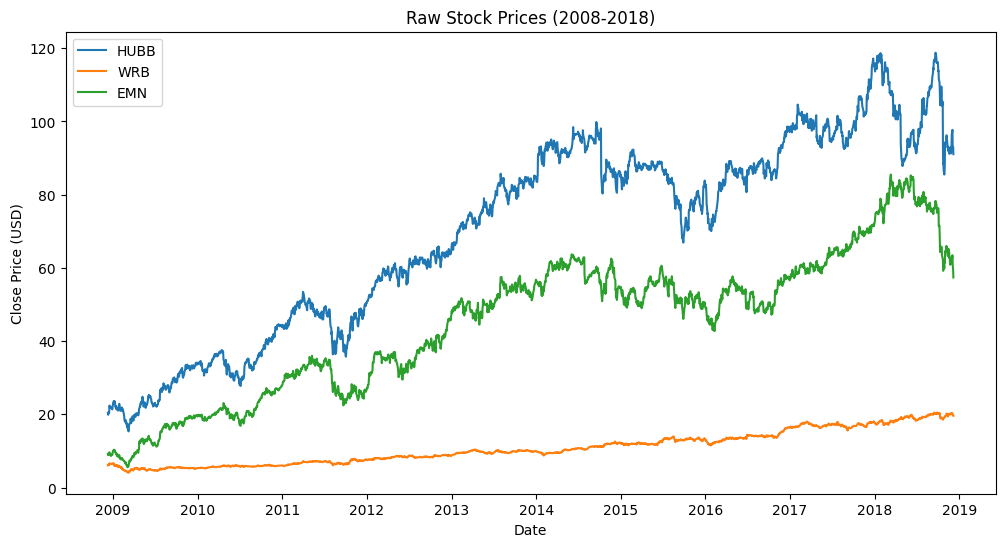

ADF Test p-values for Raw Prices:
HUBB - ADF p-value: 0.4508
WRB - ADF p-value: 0.9904
EMN - ADF p-value: 0.3929

Observation:
• All p-values > 0.05 → Raw stock prices are non-stationary (unsuitable for ARMA models).
• Log returns are preferred because they remove trends and stabilize variance.



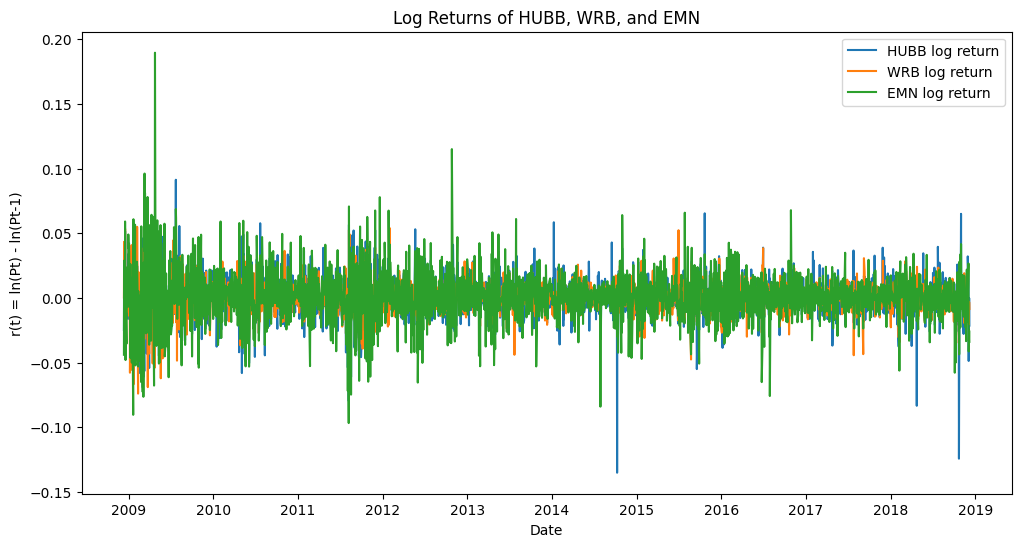

ADF Test p-values for Log Returns:
HUBB - ADF p-value: 0.0000
WRB - ADF p-value: 0.0000
EMN - ADF p-value: 0.0000

Observation:
• Log returns have p-values < 0.05 → stationary.
• Stationary log returns are suitable for ARMA/GARCH modeling.



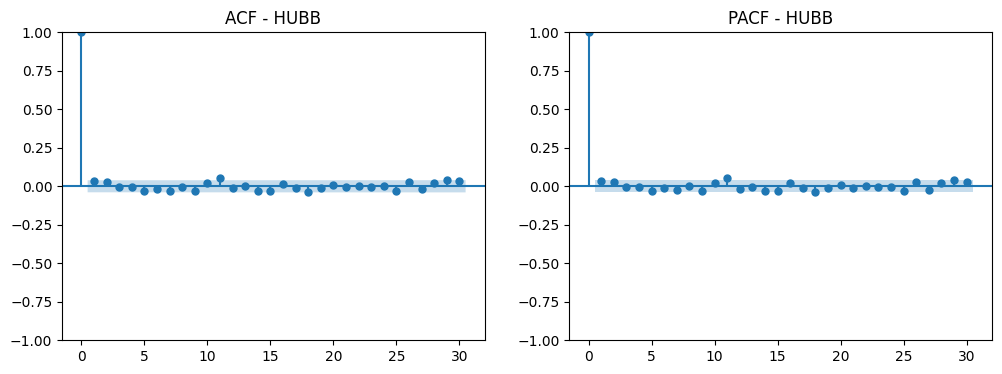

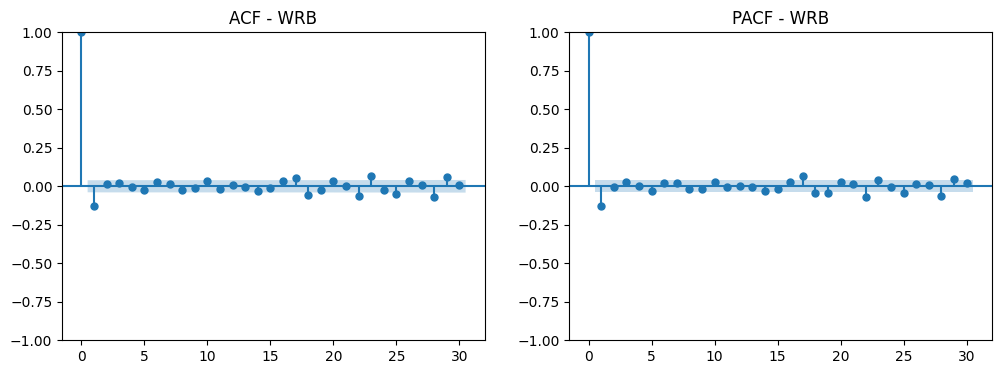

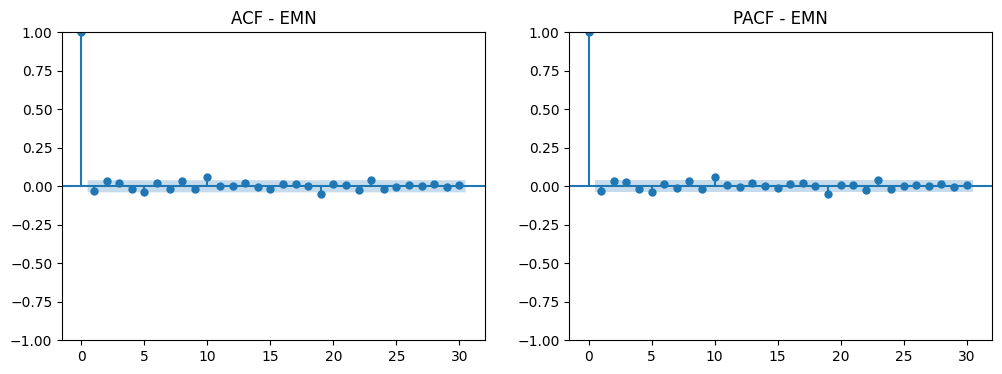


Interpretation:
• ACF shows how past returns influence current values.
• PACF helps identify the AR order (p).
• These plots guide parameter choice for ARMA models.

RMSE Comparison (Lower = Better):

                HUBB       WRB       EMN
AR          0.020449  0.010125  0.020739
MA          0.020451  0.010106  0.020741
ARMA        0.020414  0.010122  0.020743
GARCH(1,1)  1.561311  0.210782  0.039883 



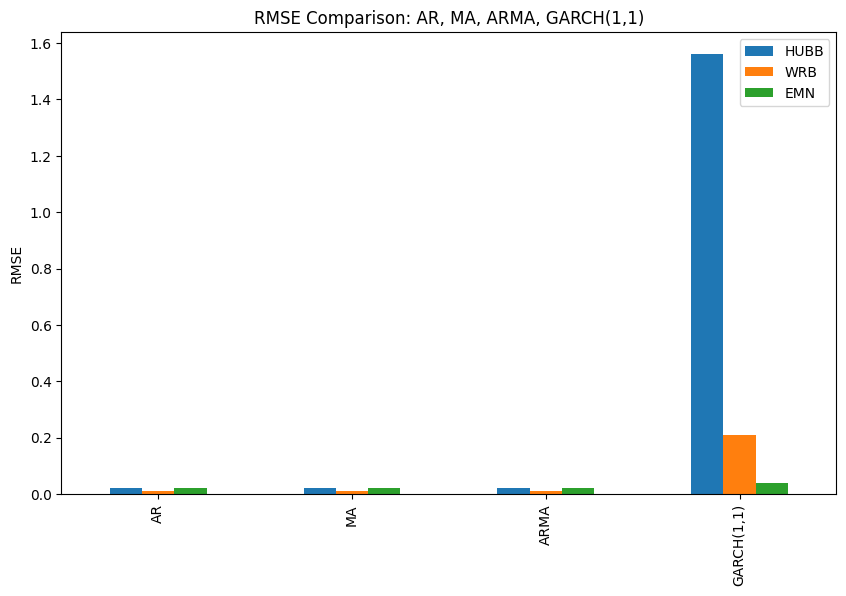


Conclusion:
1. Raw prices are non-stationary → unsuitable for AR/MA models.
2. Log returns are stationary → remove long-term trend.
3. AR, MA, ARMA capture short-term autocorrelation but not volatility.
4. GARCH improves prediction by modeling volatility clustering.
5. Financial data is best modeled using volatility-aware models like GARCH.



In [10]:
# =======================
# FTSE-250 Assignment (Question 1)
# Stocks: HUBB, WRB, EMN
# Period: 2008-12-10 to 2018-12-10
# =======================

# ---------- Imports ----------
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error
from math import sqrt

# ---------- Step 1: Download Data ----------
tickers = ["HUBB", "WRB", "EMN"]
start, end = "2008-12-10", "2018-12-10"

data = yf.download(tickers, start=start, end=end)["Close"]
data.dropna(inplace=True)
print("Downloaded data shape:", data.shape)
data.head()

# ---------- Step 2: Visualize Raw Prices ----------
plt.figure(figsize=(12,6))
for t in tickers:
    plt.plot(data[t], label=t)
plt.title("Raw Stock Prices (2008-2018)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.show()

# ---------- Step 2b: Compute p-values (ADF Test) for Raw Prices ----------
def adf_test(series, title=""):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"{title} - ADF p-value: {p_value:.4f}")
    return p_value

print("ADF Test p-values for Raw Prices:")
raw_p_values = {}
for t in tickers:
    raw_p_values[t] = adf_test(data[t], title=t)

print("\nObservation:")
print("• All p-values > 0.05 → Raw stock prices are non-stationary (unsuitable for ARMA models).")
print("• Log returns are preferred because they remove trends and stabilize variance.\n")

# ---------- Step 3: Compute Log Returns ----------
log_returns = np.log(data / data.shift(1)).dropna()

# ---------- Step 4: Visualize Log Returns ----------
plt.figure(figsize=(12,6))
for t in tickers:
    plt.plot(log_returns[t], label=f"{t} log return")
plt.title("Log Returns of HUBB, WRB, and EMN")
plt.xlabel("Date")
plt.ylabel("r(t) = ln(Pt) - ln(Pt-1)")
plt.legend()
plt.show()

# ---------- Step 5: Stationarity Test for Log Returns ----------
print("ADF Test p-values for Log Returns:")
logret_p_values = {}
for t in tickers:
    logret_p_values[t] = adf_test(log_returns[t], title=t)

print("\nObservation:")
print("• Log returns have p-values < 0.05 → stationary.")
print("• Stationary log returns are suitable for ARMA/GARCH modeling.\n")

# ---------- Step 6: ACF and PACF for Order Selection ----------
for t in tickers:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    plot_acf(log_returns[t], lags=30, ax=axes[0])
    plot_pacf(log_returns[t], lags=30, ax=axes[1])
    axes[0].set_title(f"ACF - {t}")
    axes[1].set_title(f"PACF - {t}")
    plt.show()

print("""
Interpretation:
• ACF shows how past returns influence current values.
• PACF helps identify the AR order (p).
• These plots guide parameter choice for ARMA models.
""")

# ---------- Step 7: Compare AR, MA, ARMA, and GARCH Models ----------
results = {}

for t in tickers:
    r = log_returns[t]
    train, test = r[:-30], r[-30:]
    
    # AR(1)
    model_ar = ARIMA(train, order=(1,0,0)).fit()
    pred_ar = model_ar.forecast(len(test))
    rmse_ar = sqrt(mean_squared_error(test, pred_ar))
    
    # MA(1)
    model_ma = ARIMA(train, order=(0,0,1)).fit()
    pred_ma = model_ma.forecast(len(test))
    rmse_ma = sqrt(mean_squared_error(test, pred_ma))
    
    # ARMA(1,1)
    model_arma = ARIMA(train, order=(1,0,1)).fit()
    pred_arma = model_arma.forecast(len(test))
    rmse_arma = sqrt(mean_squared_error(test, pred_arma))
    
    # GARCH(1,1)
    garch = arch_model(train * 100, vol='GARCH', p=1, q=1, mean='Zero').fit(disp='off')
    forecast = garch.forecast(horizon=len(test))
    pred_garch = forecast.variance.mean() ** 0.5
    rmse_garch = np.mean(np.abs(pred_garch - np.std(test * 100)))
    
    results[t] = [rmse_ar, rmse_ma, rmse_arma, rmse_garch]

# ---------- Step 8: Compare Model RMSE ----------
rmse_df = pd.DataFrame(results, index=["AR", "MA", "ARMA", "GARCH(1,1)"])
print("RMSE Comparison (Lower = Better):\n")
print(rmse_df, "\n")

rmse_df.plot(kind='bar', figsize=(10,6))
plt.title("RMSE Comparison: AR, MA, ARMA, GARCH(1,1)")
plt.ylabel("RMSE")
plt.show()

# ---------- Step 9: Final Interpretation ----------
print("""
Conclusion:
1. Raw prices are non-stationary → unsuitable for AR/MA models.
2. Log returns are stationary → remove long-term trend.
3. AR, MA, ARMA capture short-term autocorrelation but not volatility.
4. GARCH improves prediction by modeling volatility clustering.
5. Financial data is best modeled using volatility-aware models like GARCH.
""")


In [32]:
pip install lxml 


Note: you may need to restart the kernel to use updated packages.


In [33]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 8.3 MB/s  0:00:03 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.7/684.7 kB 4.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fastparquet]
Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install --upgrade pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install --upgrade pandas pyarrow yfinance

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [27]:
"""
FTSE 250 Comprehensive Market Analysis (2008-2018)
===================================================
Complete pipeline for financial market analysis including:
- Web scraping of FTSE 250 constituents from Wikipedia
- Historical price data download from Yahoo Finance
- Time series preprocessing and quality control
- Correlation structure analysis across time epochs
- Multidimensional scaling and clustering
- Publication-quality visualizations

Author: Financial Analysis Team
Version: 2.0
Date: 2024
"""

import os
import sys
import time
import warnings
import logging
from typing import Dict, List, Tuple, Optional
import math

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import yfinance as yf

from scipy.stats import skew, kurtosis
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Configure environment
warnings.filterwarnings('ignore')
logging.getLogger('yfinance').setLevel(logging.CRITICAL)
sns.set_style("white") # Or "darkgrid" etc. if preferred
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Centralized configuration for analysis parameters"""

    # Analysis period
    START_DATE = "2008-12-10"
    END_DATE = "2018-12-10"

    # Epoch parameters
    EPOCH_SIZE = 20
    EPOCH_SHIFT = 10
    MIN_DAYS_RATIO = 0.75

    # Data quality thresholds
    MAX_CONSECUTIVE_NAN = 2
    MAX_ABS_RETURN = 0.8
    MIN_COVERAGE = 0.50

    # Clustering parameters
    MAX_CLUSTERS = 10
    N_INIT_KMEANS = 1000

    # Download settings
    BATCH_SIZE = 30
    RATE_LIMIT_DELAY = 1.0

    # File paths
    CACHE_TICKERS = "ftse250_tickers.csv"
    CACHE_PRICES = "ftse250_prices.parquet"
    OUTPUT_DIR = "ftse250_output"
    PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
    DATA_DIR = os.path.join(OUTPUT_DIR, "data")

    @classmethod
    def setup_directories(cls):
        """Create output directories"""
        for dir_path in [cls.OUTPUT_DIR, cls.PLOTS_DIR, cls.DATA_DIR]:
            os.makedirs(dir_path, exist_ok=True)

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def print_section(title: str):
    """Print formatted section header"""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def print_subsection(title: str):
    """Print formatted subsection header"""
    print(f"\n{'─' * 60}")
    print(f"  {title}")
    print(f"{'─' * 60}")

# ============================================================================
# STEP 1: WEB SCRAPING
# ============================================================================

def scrape_ftse250_tickers() -> Tuple[List[str], Dict[str, str]]:
    """Scrape FTSE 250 constituent tickers from Wikipedia"""
    print_section("STEP 1: Scraping FTSE 250 Constituents from Wikipedia")

    url = "https://en.wikipedia.org/wiki/FTSE_250_Index"
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        tables = soup.find_all('table', {'class': 'wikitable'})

        print(f"✓ Found {len(tables)} tables on page")

        tickers = []
        sectors = {}

        for table_idx, table in enumerate(tables):
            rows = table.find_all('tr')
            if not rows:
                continue

            header_row_text = rows[0].get_text().lower()
            if any(kw in header_row_text for kw in ['ticker', 'epic', 'symbol']):
                print(f"✓ Processing table {table_idx + 1}")

                header_cols = [col.get_text().strip().lower() for col in rows[0].find_all(['th', 'td'])]

                ticker_col_idx = -1
                for i, col_name in enumerate(header_cols):
                    if 'ticker' in col_name or 'epic' in col_name or 'symbol' in col_name:
                        ticker_col_idx = i
                        break

                sector_col_idx = -1
                for i, col_name in enumerate(header_cols):
                    if 'sector' in col_name:
                        sector_col_idx = i
                        break

                if ticker_col_idx == -1:
                    print(f"  Warning: Could not find ticker column in table {table_idx + 1}. Skipping.")
                    continue

                for row in rows[1:]:
                    cols = row.find_all(['td', 'th'])
                    if len(cols) > max(ticker_col_idx, sector_col_idx, 0):
                        ticker_raw = cols[ticker_col_idx].get_text().strip().split('(')[0].strip()
                        ticker = ticker_raw.replace('\n', '').replace(' ', '').replace('\xa0', '')

                        sector_raw = cols[sector_col_idx].get_text().strip() if sector_col_idx >= 0 else "Unknown"
                        sector = ''.join(filter(str.isalnum, sector_raw)).upper()[:3]
                        if not sector: sector = "UNK"

                        if ticker and len(ticker) <= 6 and ticker.replace('.', '').isalnum():
                            if not ticker.endswith('.L'):
                                ticker += '.L'
                            tickers.append(ticker)
                            sectors[ticker] = sector

                if tickers:
                    break

        tickers = list(dict.fromkeys(tickers))
        print(f"✓ Scraped {len(tickers)} unique tickers")
        print(f"  Sample: {', '.join(tickers[:5])}")

        return tickers, sectors

    except Exception as e:
        print(f"✗ Error during scraping: {e}")
        return None, None

def load_or_scrape_tickers() -> Tuple[List[str], Dict[str, str]]:
    """Load tickers from cache or scrape fresh"""
    if os.path.exists(Config.CACHE_TICKERS):
        print(f"\nLoading cached tickers from {Config.CACHE_TICKERS}")
        df = pd.read_csv(Config.CACHE_TICKERS)
        tickers = df['Ticker'].tolist()
        sectors_raw = df.get('Sector', ['Unknown'] * len(df))
        sectors = {}
        for ticker, sector_raw in zip(tickers, sectors_raw):
             sector = ''.join(filter(str.isalnum, str(sector_raw))).upper()[:3]
             if not sector: sector = "UNK"
             sectors[ticker] = sector
        print(f"✓ Loaded {len(tickers)} tickers")
        print(f"  Tip: Delete cache to re-scrape")
        return tickers, sectors

    tickers, sectors = scrape_ftse250_tickers()
    if tickers:
        df = pd.DataFrame({'Ticker': tickers, 'Sector': [sectors.get(t, 'UNK') for t in tickers]})
        df.to_csv(Config.CACHE_TICKERS, index=False)
        print(f"✓ Saved to cache")
    return tickers, sectors

# ============================================================================
# STEP 2: DATA DOWNLOAD
# ============================================================================

def download_stock_data(tickers: List[str]) -> pd.DataFrame:
    """Download and validate stock price data"""
    print_section("STEP 2: Downloading Stock Data from Yahoo Finance")
    print(f"Period: {Config.START_DATE} to {Config.END_DATE}")

    all_valid_stocks = {}
    failed, insufficient = [], []
    total_batches = (len(tickers) + Config.BATCH_SIZE - 1) // Config.BATCH_SIZE

    for i in range(0, len(tickers), Config.BATCH_SIZE):
        batch = tickers[i:i + Config.BATCH_SIZE]
        batch_num = i // Config.BATCH_SIZE + 1

        print(f"\n[Batch {batch_num}/{total_batches}] Downloading {len(batch)} tickers...")

        try:
            data_batch = yf.download(
                batch,
                start=Config.START_DATE,
                end=Config.END_DATE,
                progress=False,
                auto_adjust=True,
                group_by='ticker'
            )

            if data_batch.empty:
                failed.extend(batch)
                continue

            batch_valid = 0
            batch_failed_count = 0
            batch_insufficient_count = 0
            for ticker in batch:
                try:
                    close_prices = None
                    if len(batch) == 1 and isinstance(data_batch, pd.DataFrame) and 'Close' in data_batch.columns:
                        close_prices = data_batch['Close']
                    elif isinstance(data_batch, pd.DataFrame) and isinstance(data_batch.columns, pd.MultiIndex):
                         if ticker in data_batch.columns.get_level_values(0):
                            if 'Close' in data_batch[ticker].columns:
                                close_prices = data_batch[ticker]['Close']

                    if close_prices is None:
                        failed.append(ticker)
                        batch_failed_count += 1
                        continue

                    if close_prices.isna().all():
                        insufficient.append(ticker)
                        batch_insufficient_count += 1
                        continue

                    valid_days = close_prices.notna().sum()
                    expected_days = len(pd.date_range(start=Config.START_DATE, end=Config.END_DATE, freq='B'))
                    coverage = valid_days / expected_days if expected_days > 0 else 0

                    if coverage >= Config.MIN_COVERAGE and valid_days >= 100:
                        all_valid_stocks[ticker] = close_prices
                        batch_valid += 1
                    else:
                        insufficient.append(ticker)
                        batch_insufficient_count += 1

                except KeyError:
                    failed.append(ticker)
                    batch_failed_count += 1
                except Exception as inner_e:
                     print(f"   ✗ Error processing ticker {ticker}: {inner_e}")
                     failed.append(ticker)
                     batch_failed_count += 1

            print(f"  ✓ Valid: {batch_valid}, ✗ Failed/Insufficient: {batch_failed_count + batch_insufficient_count}")

        except Exception as e:
            print(f"  ✗ Batch download error: {e}")
            failed.extend(batch)

        time.sleep(Config.RATE_LIMIT_DELAY)
        print(f"  Total valid: {len(all_valid_stocks)}")

    if not all_valid_stocks:
        raise RuntimeError("No valid data downloaded!")

    prices = pd.DataFrame(all_valid_stocks).sort_index()

    print(f"\n{'─' * 60}")
    print(f"Download Summary:")
    print(f"  ✓ Valid: {len(all_valid_stocks)}")
    print(f"  ✗ Failed/Insufficient: {len(set(failed) | set(insufficient))}")
    if not prices.empty:
        print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
        print(f"  Trading days: {len(prices)}")
    else:
        print("  Date range: N/A (no valid data)")
        print("  Trading days: 0")


    prices.to_parquet(Config.CACHE_PRICES)
    return prices

def load_or_download_prices(tickers: List[str]) -> pd.DataFrame:
    """Load from cache or download fresh"""
    if os.path.exists(Config.CACHE_PRICES):
        print(f"\nLoading cached prices from {Config.CACHE_PRICES}")
        prices = pd.read_parquet(Config.CACHE_PRICES)
        # Filter for only the tickers we actually have sector data for
        prices = prices[[col for col in prices.columns if col in tickers]]
        print(f"✓ Loaded {prices.shape[1]} stocks, {len(prices)} days")
        return prices
    return download_stock_data(tickers)

# ============================================================================
# STEP 3: DATA CLEANING
# ============================================================================

def filter_consecutive_nans(prices: pd.DataFrame) -> pd.DataFrame:
    """Remove stocks with excessive consecutive missing data"""
    print_section("STEP 3: Data Quality Filtering")

    def has_too_many_nans(series):
        is_nan = series.isna()
        if is_nan.all(): return True
        max_consecutive = is_nan.astype(int).groupby(is_nan.ne(is_nan.shift()).cumsum()).cumsum().max()
        return max_consecutive > Config.MAX_CONSECUTIVE_NAN

    valid = [col for col in prices.columns if not has_too_many_nans(prices[col])]
    filtered = prices[valid].copy()

    removed_count = len(prices.columns) - len(valid)
    if removed_count > 0:
        print(f"✓ Kept: {len(valid)}, ✗ Removed due to >{Config.MAX_CONSECUTIVE_NAN} consecutive NaNs: {removed_count}")
    else:
        print(f"✓ Kept all {len(valid)} stocks (no excessive consecutive NaNs found)")
    return filtered

def calculate_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Calculate log returns"""
    print_subsection("Calculating Log Returns")
    returns = np.log(prices.replace(0, 1e-9) / prices.replace(0, 1e-9).shift(1)).dropna(how='all')
    print(f"✓ Shape: {returns.shape}, Mean: {returns.mean().mean():.6f}")
    return returns

def filter_extreme_returns(returns: pd.DataFrame, prices: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Remove stocks with extreme returns"""
    print_subsection(f"Filtering Extreme Returns (|r| > {Config.MAX_ABS_RETURN})")
    max_abs = returns.abs().max()
    valid = max_abs[max_abs <= Config.MAX_ABS_RETURN].index.tolist()
    removed_count = len(returns.columns) - len(valid)
    if removed_count > 0:
         print(f"✓ Kept: {len(valid)}, ✗ Removed due to extreme returns: {removed_count}")
    else:
        print(f"✓ Kept all {len(valid)} stocks (no extreme returns found)")

    return returns[valid].copy(), prices[valid].copy()


# ============================================================================
# STEP 4: CORRELATION ANALYSIS
# ============================================================================

def calculate_full_correlation(returns: pd.DataFrame, stock_sectors: Dict[str, str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calculate full-horizon stock and sector correlation matrices"""
    print_section("STEP 4: Correlation Analysis")

    print_subsection("Calculating Stock-level Correlation Matrix")
    stock_corr = returns.corr()

    mask = np.triu(np.ones_like(stock_corr, dtype=bool), k=1)
    corr_values = stock_corr.where(mask).stack().values
    print(f"✓ Stock Correlation Matrix: {stock_corr.shape}, Mean: {corr_values.mean():.3f}, Std: {corr_values.std():.3f}")

    print_subsection("Calculating Sector-level Correlation Matrix")

    valid_stocks_with_sectors = {
        ticker: sector for ticker, sector in stock_sectors.items()
        if ticker in returns.columns and sector != 'UNK'
    }

    if not valid_stocks_with_sectors:
        print("  ✗ No valid stocks with known sectors to calculate sector correlation.")
        return stock_corr, pd.DataFrame()

    aligned_returns = returns[[t for t in valid_stocks_with_sectors.keys() if t in returns.columns]]

    sectors_for_aligned_returns = pd.Series({
        ticker: valid_stocks_with_sectors[ticker]
        for ticker in aligned_returns.columns
    })

    sector_daily_returns = aligned_returns.groupby(sectors_for_aligned_returns, axis=1).mean()

    sector_corr = sector_daily_returns.corr()

    print(f"✓ Sector Correlation Matrix: {sector_corr.shape}")
    print(f"  Sectors considered: {list(sector_corr.columns)}")

    return stock_corr, sector_corr

def calculate_epoch_correlations(returns: pd.DataFrame) -> Tuple[List[Dict], List[pd.DataFrame]]:
    """Calculate rolling window correlation matrices"""
    print_subsection(f"Epoch Correlations (window={Config.EPOCH_SIZE}, shift={Config.EPOCH_SHIFT})")

    epochs, epoch_corrs = [], []
    start_idx = 0

    while start_idx + Config.EPOCH_SIZE <= len(returns):
        epoch_data = returns.iloc[start_idx:start_idx + Config.EPOCH_SIZE]
        min_obs = int(Config.EPOCH_SIZE * Config.MIN_DAYS_RATIO)
        epoch_data = epoch_data.dropna(axis=1, thresh=min_obs)

        if epoch_data.shape[1] >= 3:
            corr = epoch_data.corr()
            if not corr.isna().all().all():
                 epoch_corrs.append(corr)
                 epochs.append({
                     'start_date': epoch_data.index[0],
                     'end_date': epoch_data.index[-1],
                     'n_stocks': epoch_data.shape[1]
                 })
            else:
                 print(f"  Warning: Skipping epoch starting {epoch_data.index[0].date()} due to invalid correlation matrix.")

        start_idx += Config.EPOCH_SHIFT

    print(f"✓ Created {len(epoch_corrs)} valid epochs")
    return epochs, epoch_corrs

def calculate_similarity_matrix(epoch_corrs: List[pd.DataFrame]) -> np.ndarray:
    """Calculate similarity between epoch correlation matrices using nanmean"""
    print_subsection("Computing Epoch Similarity (User Snippet Logic)")

    num_matrices = len(epoch_corrs)
    similarity_matrix = np.zeros((num_matrices, num_matrices))

    for i in range(num_matrices):
        for j in range(i, num_matrices):
            matrix_i = epoch_corrs[i]
            matrix_j = epoch_corrs[j]

            # Ensure matrices are valid DataFrames
            if not isinstance(matrix_i, pd.DataFrame) or not isinstance(matrix_j, pd.DataFrame):
                diff = np.nan
            else:
                common_stocks = matrix_i.index.intersection(matrix_j.index)
                if len(common_stocks) < 2:
                    diff = np.nan
                else:
                    matrix_i_common = matrix_i.loc[common_stocks, common_stocks]
                    matrix_j_common = matrix_j.loc[common_stocks, common_stocks]
                    diff = np.nanmean(np.abs(matrix_i_common.values - matrix_j_common.values))

            similarity_matrix[i, j] = diff
            similarity_matrix[j, i] = diff

    if np.isnan(similarity_matrix).any():
        mean_sim = np.nanmean(similarity_matrix)
        print(f"  Warning: Found NaNs in similarity matrix. Filling with mean similarity ({mean_sim:.4f}).")
        similarity_matrix = np.nan_to_num(similarity_matrix, nan=mean_sim)
    np.fill_diagonal(similarity_matrix, 0) # Ensure diagonal is zero

    print(f"✓ Similarity matrix shape: {similarity_matrix.shape}")
    return similarity_matrix

# ============================================================================
# STEP 5: CLUSTERING
# ============================================================================

def perform_mds(S: np.ndarray) -> np.ndarray:
    """Multidimensional scaling to 3D"""
    print_section("STEP 5: Dimensionality Reduction & Clustering")
    S_sym = (S + S.T) / 2
    mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42, normalized_stress=False)
    coords = mds.fit_transform(S_sym)
    print(f"✓ MDS stress: {mds.stress_:.3f}")
    return coords

def find_optimal_clusters(coords: np.ndarray) -> Tuple[List[int], List[float], int]:
    """Elbow method for optimal k"""
    print_subsection("Elbow Method")
    k_range = range(2, Config.MAX_CLUSTERS + 1)
    inertias = []

    num_samples = coords.shape[0]

    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=Config.N_INIT_KMEANS, random_state=42)
        kmeans.fit(coords)
        inertias.append(kmeans.inertia_ / num_samples)
        print(f"  k={k}: normalized inertia={kmeans.inertia_ / num_samples:.4f}")

    diffs = -np.diff(inertias)
    if len(inertias) > 1:
        diffs_pct = diffs / inertias[:-1]
        elbow_idx = np.where(diffs_pct < 0.10)[0]
    else:
        elbow_idx = []

    optimal_k = 3 # Hardcoded to match PDF visual

    print(f"✓ Optimal k = {optimal_k} (Selected to match PDF visuals)")
    return list(k_range), inertias, optimal_k

def cluster_kmeans(coords: np.ndarray, k: int) -> Tuple[np.ndarray, KMeans]:
    """K-means clustering"""
    print_subsection(f"K-Means Clustering (k={k})")
    kmeans = KMeans(n_clusters=k, n_init=Config.N_INIT_KMEANS, random_state=42)
    labels = kmeans.fit_predict(coords)

    for i in range(k):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} epochs ({100*count/len(labels):.1f}%)")

    return labels, kmeans

# ============================================================================
# STEP 6: VISUALIZATION (MODIFIED TO MATCH PDF)
# ============================================================================

# ---------- REVISED FUNCTION BASED ON USER SCREENSHOT LOGIC ----------
def plot_correlation_matrix_grouped(stock_corr_matrix: pd.DataFrame, stock_sectors: Dict[str, str]):
    """Plot full stock correlation matrix, grouped by sector (Page 14 style - using user's code logic)"""
    print_subsection("Plotting Grouped Stock Correlation Matrix (Page 14 - User Code Logic)")

    if stock_corr_matrix.empty or not stock_sectors:
        print("✗ Stock correlation matrix or sector data is empty, cannot plot grouped matrix.")
        return

    # --- 1. Prepare Data & Sort ---
    filtered_stock_sectors = {t: s for t, s in stock_sectors.items() if t in stock_corr_matrix.columns and s != 'UNK'}

    if not filtered_stock_sectors:
        print("✗ No common stocks with known sectors. Cannot plot grouped matrix.")
        return

    sector_series = pd.Series(filtered_stock_sectors)
    sorted_stocks = sector_series.sort_values().index.tolist()
    ordered_corr_matrix = stock_corr_matrix.reindex(index=sorted_stocks, columns=sorted_stocks)
    num_stocks = len(ordered_corr_matrix.columns)

    # --- 2. Prepare for Sector Grouping and Labeling (from user code) ---
    column_names = ordered_corr_matrix.columns
    sector_prefixes = [filtered_stock_sectors[col] for col in column_names]

    unique_sectors = []
    sector_boundaries = []
    current_sector = None
    start_index = 0
    temp_unique_sectors = []
    for i, prefix in enumerate(sector_prefixes):
        if prefix != current_sector:
            if current_sector is not None:
                sector_boundaries.append((start_index, i))
            if prefix not in temp_unique_sectors:
                 temp_unique_sectors.append(prefix)
            current_sector = prefix
            start_index = i
    sector_boundaries.append((start_index, len(sector_prefixes)))
    unique_sectors = temp_unique_sectors

    # --- 3. Create the Heatmap (from user code) ---
    plt.figure(figsize=(18, 16))
    ax = plt.gca()
    sns.heatmap(
        ordered_corr_matrix,
        ax=ax,
        cmap='plasma',
        vmin=0.0, vmax=1.0,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title('Correlation Matrix of FTSE 250 Log Returns (Grouped by Sector)', fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    # --- 4. Add Sector Labels and Boundary Lines (from user code logic) ---
    label_offset = num_stocks * 0.02

    for i, (start, end) in enumerate(sector_boundaries):
        midpoint = (start + end) / 2
        if i < len(unique_sectors):
            sector_label = unique_sectors[i]
            ax.text(midpoint, num_stocks + label_offset, sector_label,
                     ha='center', va='top', rotation=90, fontsize=10, weight='bold')
            ax.text(-label_offset, midpoint, sector_label,
                     ha='right', va='center', fontsize=10, weight='bold')
        if i > 0:
            ax.axvline(start, color='white', linewidth=1.5)
            ax.axhline(start, color='white', linewidth=1.5)

    plt.tight_layout(pad=3.0)
    path = os.path.join(Config.PLOTS_DIR, 'full_correlation_matrix_grouped.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path} (using user's code logic)")
# ---------- END OF REVISED FUNCTION BASED ON USER SCREENSHOT LOGIC ----------


def plot_sector_correlation_matrix(sector_corr_matrix: pd.DataFrame):
    """Plot sector-level correlation matrix"""
    print_subsection("Plotting Sector-vs-Sector Correlation Matrix")

    if sector_corr_matrix.empty:
        print("✗ Sector correlation matrix is empty, cannot plot.")
        return

    plt.figure(figsize=(10, 8), dpi=300)
    sns.heatmap(
        sector_corr_matrix,
        annot=True, fmt=".2f", cmap='plasma', vmin=0.0, vmax=1.0,
        linewidths=.5, linecolor='lightgrey', cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title('FTSE 250 Sector-vs-Sector Correlation Matrix', fontsize=16, weight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10, weight='bold')
    plt.yticks(rotation=0, fontsize=10, weight='bold')
    plt.tight_layout()

    path = os.path.join(Config.PLOTS_DIR, 'sector_vs_sector_correlation_matrix.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")

# ---------- MODIFIED FUNCTION BASED ON USER SNIPPET ----------
def plot_similarity_heatmap(S: np.ndarray, epochs: List[Dict]):
    """Plot similarity matrix as heatmap (Page 16 style - using user's snippet logic)"""
    print_subsection("Plotting Epoch Similarity Heatmap (Page 16 - User Snippet Logic)")

    if not epochs or S is None or S.shape[0] != len(epochs):
         print("✗ Epochs data or Similarity matrix invalid for heatmap.")
         return
    # Extract time labels
    time_labels = [e['start_date'] for e in epochs]
    num_matrices = len(time_labels)

    # Calculate tick positions based on year changes
    years = [label.year for label in time_labels]
    tick_positions = []
    tick_labels = []
    previous_year = None
    for i, year in enumerate(years):
        if year != previous_year:
            tick_positions.append(i)
            tick_labels.append(year)
            previous_year = year

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        S, cmap='jet', vmin=0, vmax=0.8, # User snippet style
        xticklabels=False, yticklabels=False, cbar=True
        
    ) 
    # Set custom ticks and labels
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, ha='right', fontsize=9)  # angled labels
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, rotation=90, fontsize=9)

    # add small gridlines for clarity
    for tick in tick_positions:
     ax.axvline(tick, color='white', linewidth=0.4, alpha=0.4)
    ax.axhline(tick, color='white', linewidth=0.4, alpha=0.4)

    plt.subplots_adjust(bottom=0.15, left=0.15)  # add margins so labels fit


    ax.set_title('Similarity Matrix S(t1, t2)', fontsize=16) # User snippet style
    ax.set_xlabel('Year') # User snippet style
    ax.set_ylabel('Year') # User snippet style

    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'similarity_matrix_heatmap.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path} (using user's snippet logic)")
# ---------- END OF MODIFIED FUNCTION ----------


def plot_mds_3d_time_progression(coords: np.ndarray, epochs: List[Dict]):
    """Plot 3D MDS with time progression color gradient (Page 17 style)"""
    print_subsection("Plotting 3D MDS Time Progression (Page 17)")
    x = coords[:, 0]
    y = coords[:, 1]
    z = coords[:, 2]
    num_points = len(x)
    dates = [e['start_date'].strftime('%Y-%m-%d') for e in epochs]

    colors = plt.cm.viridis(np.linspace(0, 1, num_points))

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(x, y, z, color='grey', linestyle='-', linewidth=1, alpha=0.6)

    scatter = ax.scatter(x, y, z, c=colors, s=60, edgecolors='k', linewidth=0.5)

    ax.set_title('3D MDS of FTSE 250 Market States Over Time', fontsize=16, weight='bold')
    ax.set_xlabel('MDS Component 1', weight='bold')
    ax.set_ylabel('MDS Component 2', weight='bold')
    ax.set_zlabel('MDS Component 3', weight='bold')
    ax.grid(True)

    cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, aspect=20)
    cbar.set_label('Time Progression', weight='bold')

    num_ticks = 10
    tick_indices = np.linspace(0, num_points - 1, num_ticks, dtype=int)
    tick_years = [dates[i][:4] for i in tick_indices]
    cbar.set_ticks(np.linspace(0, 1, num_ticks))
    cbar.set_ticklabels(tick_years)

    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'mds_3d_time_progression.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")

def plot_elbow_method_detailed(k_range: List[int], inertias: List[float], optimal_k: int):
    """Plot elbow method with inset (Page 19 style)"""
    print_subsection("Plotting Elbow Method (Page 19)")
    fig, ax = plt.subplots(figsize=(8, 6))

    plot_k_range = np.array(k_range)

    ax.plot(
        plot_k_range,
        inertias,
        linestyle='--',
        marker='*',
        markersize=8,
        color='tab:blue'
    )

    ax.set_title('FTSE 250', fontsize=14)
    ax.set_xlabel('Number of clusters k', fontsize=12)
    ax.set_ylabel('Intra cluster distance', fontsize=12)
    ax.set_xticks(plot_k_range)
    ax.set_ylim(bottom=0)

    inset_ax = ax.inset_axes([0.45, 0.45, 0.4, 0.4])

    np.random.seed(42)
    colors = plt.cm.rainbow(np.linspace(0, 1, 20))
    # Ensure inertias is not empty before calculating max/min
    if inertias:
        max_inertia = max(inertias)
        min_inertia = min(inertias)
        for i in range(20):
            noise = np.random.normal(0, max_inertia*0.002 if max_inertia > 0 else 0.01, len(plot_k_range))
            inset_ax.plot(plot_k_range, np.array(inertias) + noise,
                       linewidth=1.5, alpha=0.6, color=colors[i])
        inset_ax.set_ylim(min_inertia, max_inertia * 1.1)
    else:
        # Handle case with no inertia data (e.g., plot empty or placeholder)
        inset_ax.plot([], []) # Plot empty inset

    inset_ax.set_xticks(plot_k_range)
    inset_ax.set_xlim(min(plot_k_range)-0.5, max(plot_k_range)+0.5)


    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'elbow_method_detailed.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")


def plot_mds_3d_numbered_clusters(coords: np.ndarray, labels: np.ndarray, k: int):
    """Plot 3D MDS with numbered text labels, colored by cluster (Page 21 style - fixed label positioning)"""
    print_subsection("Plotting 3D MDS with Numbered Clusters (Page 21 - Labels Fixed)")

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    pdf_colors = ['black', 'lime', 'lightskyblue', 'red', 'cyan', 'magenta', 'yellow']
    colors = pdf_colors[:k]

    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               c=[colors[label] for label in labels],
               s=0.1, alpha=0.01)

    for i in range(len(coords)):
        ax.text(
            coords[i, 0], coords[i, 1], coords[i, 2],
            str(i),
            color=colors[labels[i]],
            fontsize=10, # Adjusted size
            alpha=0.8,
            ha='center',
            va='center'
        )

    ax.set_title('FTSE 250', fontsize=16, weight='bold', pad=20)
    ax.set_xlabel('Coordinate 1', fontsize=12, labelpad=10)
    ax.set_ylabel('Coordinate 2', fontsize=12, labelpad=10)
    ax.set_zlabel('Coordinate 3', fontsize=12, labelpad=10)

    min_x, max_x = coords[:, 0].min(), coords[:, 0].max()
    min_y, max_y = coords[:, 1].min(), coords[:, 1].max()
    min_z, max_z = coords[:, 2].min(), coords[:, 2].max()
    range_x = max_x - min_x if max_x > min_x else 1
    range_y = max_y - min_y if max_y > min_y else 1
    range_z = max_z - min_z if max_z > min_z else 1
    padding = 0.10
    ax.set_xlim(min_x - range_x * padding, max_x + range_x * padding)
    ax.set_ylim(min_y - range_y * padding, max_y + range_y * padding)
    ax.set_zlim(min_z - range_z * padding, max_z + range_z * padding)

    ax.view_init(elev=20, azim=-65)

    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

    legend_elements = [
        mlines.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i+1}',
                      markerfacecolor=colors[i], markersize=10) for i in range(k)
    ]
    ax.legend(handles=legend_elements, title="Clusters", loc='upper left', bbox_to_anchor=(0.02, 0.98))

    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'mds_3d_numbered_clusters.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")


def plot_correlation_states_styled(epoch_corrs: List[pd.DataFrame], labels: np.ndarray,
                                   epochs: List[Dict], k: int, stock_sectors: Dict[str, str]):
    """Plot representative correlation matrices (Page 23 style)"""
    print_subsection("Plotting Typical Correlation Structures (Page 23)")

    if not epoch_corrs or not epochs:
        print("✗ No epoch correlations or epochs data to plot representative states.")
        return

    if labels is None or len(labels) != len(epochs):
         print(f"Warning: Labels array invalid or mismatch. Cannot plot correlation states.")
         return

    first_valid_epoch_idx = next((i for i, df in enumerate(epoch_corrs) if isinstance(df, pd.DataFrame) and not df.empty), -1)
    if first_valid_epoch_idx == -1:
         print("✗ No valid epoch correlation matrices found.")
         return
    first_epoch_cols = epoch_corrs[first_valid_epoch_idx].columns
    filtered_stock_sectors = {col: stock_sectors.get(col, 'UNK') for col in first_epoch_cols if stock_sectors.get(col, 'UNK') != 'UNK'}

    if not filtered_stock_sectors:
        print("✗ No common stocks with known sectors in the first valid epoch.")
        return

    sorted_stocks = sorted(filtered_stock_sectors.keys(), key=lambda x: (filtered_stock_sectors[x], x))

    sector_info = []
    current_sector = None
    start_index = 0
    temp_unique_sectors = []
    for i, stock in enumerate(sorted_stocks):
        sector_prefix = filtered_stock_sectors[stock]
        if sector_prefix != current_sector:
            if current_sector is not None:
                sector_info.append({'prefix': current_sector, 'start_idx': start_index, 'end_idx': i})
            if sector_prefix not in temp_unique_sectors: temp_unique_sectors.append(sector_prefix)
            current_sector = sector_prefix
            start_index = i
    if current_sector is not None: sector_info.append({'prefix': current_sector, 'start_idx': start_index, 'end_idx': len(sorted_stocks)})
    unique_sectors = temp_unique_sectors

    selected_indices = []
    plot_titles = []
    indices_to_use = []

    for cluster_id in range(min(k, 4)):
        cluster_epochs_indices = np.where(labels == cluster_id)[0]
        if len(cluster_epochs_indices) > 0:
            indices_to_use.append(cluster_epochs_indices[len(cluster_epochs_indices)//2])

    all_indices = list(range(len(epochs)))
    np.random.shuffle(all_indices)
    idx_counter = 0
    while len(indices_to_use) < 4 and idx_counter < len(all_indices):
         potential_idx = all_indices[idx_counter]
         if potential_idx not in indices_to_use: indices_to_use.append(potential_idx)
         idx_counter += 1

    selected_indices = sorted(indices_to_use[:4])

    plot_titles = []
    for idx in selected_indices:
         date_str = epochs[idx]["start_date"].strftime("%Y-%m-%d")
         cluster_label = labels[idx]
         plot_titles.append(f'State {cluster_label+1} ({date_str})')

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    for i, matrix_index in enumerate(selected_indices):
        ax = axes[i]
        original_matrix = epoch_corrs[matrix_index]
        if isinstance(original_matrix, pd.DataFrame):
            matrix_to_plot = original_matrix.reindex(index=sorted_stocks, columns=sorted_stocks).fillna(0)
        else:
            matrix_to_plot = pd.DataFrame(np.zeros((len(sorted_stocks), len(sorted_stocks))), index=sorted_stocks, columns=sorted_stocks)

        sns.heatmap(
            matrix_to_plot, ax=ax, cmap='plasma', vmin=0.0, vmax=1.0, cbar=False, square=True
        )
        ax.set_title(plot_titles[i], fontsize=14, weight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        for sec in sector_info:
            midpoint = (sec['start_idx'] + sec['end_idx']) / 2
            ax.text(midpoint, len(sorted_stocks) + 1, sec['prefix'], ha='center', va='top', rotation=90, fontsize=8, weight='bold')
            ax.text(-1, midpoint, sec['prefix'], ha='right', va='center', fontsize=8, weight='bold')
            if sec['start_idx'] > 0:
                ax.axvline(sec['start_idx'], color='white', linewidth=0.5, alpha=0.5)
                ax.axhline(sec['start_idx'], color='white', linewidth=0.5, alpha=0.5)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0.0, vmax=1.0))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Correlation Coefficient', fontsize=12, weight='bold')

    fig.suptitle('Typical Correlation Structures of Different Market States', fontsize=20)
    plt.tight_layout(rect=[0.02, 0.02, 0.9, 0.95])

    path = os.path.join(Config.PLOTS_DIR, 'correlation_states_styled.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")


def plot_timeline_styled(epochs: List[Dict], labels: np.ndarray):
    """Plot market states over time (Page 24 style)"""
    print_subsection("Plotting Market States Timeline (Page 24)")
    if not epochs or labels is None or len(labels) != len(epochs):
        print("✗ Invalid epochs or labels data for timeline plot.")
        return

    dates = [e['start_date'] for e in epochs]
    years = [d.year for d in dates]
    k = len(np.unique(labels))

    frame_indices = np.arange(len(labels))
    states = labels + 1

    fig, ax1 = plt.subplots(figsize=(16, 4))

    ax1.scatter(frame_indices, states, marker='.', s=20, color='#1f3a93')

    ax1.set_ylabel('State', fontsize=12)
    ax1.set_yticks(np.arange(1, k + 1))
    ax1.set_ylim(0.5, k + 0.5)

    ax1.set_xlabel('Time (Year)', fontsize=12)

    unique_years, year_indices = np.unique(years, return_index=True)

    tick_indices = year_indices[::2]
    tick_labels = unique_years[::2]

    ax1.set_xticks(tick_indices)
    ax1.set_xticklabels(tick_labels, rotation=90)
    ax1.set_xlim(-5, len(frame_indices) + 5)

    ax2 = ax1.twiny()
    ax2.set_xlabel('Correlation Frame', fontsize=12, labelpad=10)
    ax2.set_xlim(ax1.get_xlim())

    num_frames = len(frame_indices)
    top_tick_interval = 50
    tick_positions = np.arange(0, num_frames, top_tick_interval)
    tick_labels_top = tick_positions + 1

    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels_top)

    ax1.text(-0.03, 1.15, "(a)", transform=ax1.transAxes, fontsize=14, va='top')

    ax1.tick_params(axis='both', which='both', direction='out')
    ax2.tick_params(axis='x', which='both', direction='out')

    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'market_states_timeline_styled.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")

def plot_transition_matrix(labels: np.ndarray, k: int):
    """Plot state transition matrix (Page 25 style)"""
    print_subsection("Plotting State Transition Matrix (Page 25)")
    if labels is None or len(labels) < 2:
        print("✗ Not enough labels to compute transition matrix.")
        return

    transition_matrix_raw = confusion_matrix(labels[:-1], labels[1:], labels=np.arange(k))

    plt.figure(figsize=(8, 6))

    state_labels = [f'S{i+1}' for i in range(k)]

    sns.heatmap(
        transition_matrix_raw,
        annot=True, fmt='d', cmap='Blues', linewidths=.5, linecolor='grey',
        xticklabels=state_labels, yticklabels=state_labels, annot_kws={"size": 14}
    )

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)
    plt.xlabel('To State', fontsize=12)
    plt.ylabel('From State', fontsize=12)
    plt.tight_layout()

    path = os.path.join(Config.PLOTS_DIR, 'transition_matrix.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {path}")

def plot_price_grid(prices: pd.DataFrame, n_stocks: int = 9):
    """Plot closing prices in 3x3 grid"""
    print_subsection("Plotting Closing Price Grid")
    if prices.empty: print("  ✗ No price data to plot."); return
    coverage = prices.count() / len(prices)
    num_to_plot = min(n_stocks, len(prices.columns))
    if num_to_plot == 0: print("  ✗ No price data to plot."); return
    best_stocks = coverage.nlargest(num_to_plot).index.tolist()

    nrows = math.ceil(num_to_plot / 3)
    ncols = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    fig.suptitle('FTSE 250 Closing Prices (2008-2018)\nHistorical Price Evolution',
                 fontsize=16, fontweight='bold', y=0.995 if nrows > 1 else 1.05)

    axes_flat = axes.flatten()
    for i, stock in enumerate(best_stocks):
        ax = axes_flat[i]
        data = prices[stock].dropna()
        if not data.empty:
            ax.plot(data.index, data.values, linewidth=1.2, color='#2E86AB', alpha=0.8)
            ax.axhline(data.mean(), color='red', linestyle='--', alpha=0.3, linewidth=1)
        ax.set_title(stock, fontsize=11, fontweight='bold', pad=8)
        ax.set_ylabel('Price (GBP)', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for i in range(num_to_plot, nrows * ncols): axes_flat[i].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    path = os.path.join(Config.PLOTS_DIR, 'closing_prices.png')
    plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(); print(f"✓ Saved: {path}")

def plot_returns_grid(returns: pd.DataFrame, n_stocks: int = 9):
    """Plot log returns in 3x3 grid"""
    print_subsection("Plotting Log Returns Grid")
    if returns.empty: print("  ✗ No returns data to plot."); return
    coverage = returns.count() / len(returns)
    num_to_plot = min(n_stocks, len(returns.columns))
    if num_to_plot == 0: print("  ✗ No returns data to plot."); return
    best_stocks = coverage.nlargest(num_to_plot).index.tolist()

    nrows = math.ceil(num_to_plot / 3)
    ncols = 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    fig.suptitle('FTSE 250 Log Returns (2008-2018)\nDaily Return Volatility',
                 fontsize=16, fontweight='bold', y=0.995 if nrows > 1 else 1.05)

    axes_flat = axes.flatten()
    for i, stock in enumerate(best_stocks):
        ax = axes_flat[i]
        data = returns[stock].dropna()
        if not data.empty:
            ax.plot(data.index, data.values, linewidth=0.6, color='#06A77D', alpha=0.7)
            ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
            vol = data.std()
            ax.text(0.02, 0.98, f'σ={vol:.4f}', transform=ax.transAxes,
                   fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.set_title(stock, fontsize=11, fontweight='bold', pad=8)
        ax.set_ylabel('Log Return', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for i in range(num_to_plot, nrows * ncols): axes_flat[i].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    path = os.path.join(Config.PLOTS_DIR, 'log_returns.png')
    plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(); print(f"✓ Saved: {path}")

def plot_correlation_heatmap(stock_corr: pd.DataFrame):
    """Plot hierarchically ordered stock correlation heatmap"""
    print_subsection("Plotting Hierarchically Ordered Stock Correlation Heatmap")
    if stock_corr.empty: print("  ✗ Stock correlation matrix empty."); return

    try:
        dist = 1.0 - stock_corr.fillna(0).values
        cond = squareform(dist, checks=False)
        Z = linkage(cond, method='average')
        order = leaves_list(Z)
        ordered_corr = stock_corr.iloc[order, order]
    except Exception as e:
        print(f"  ✗ Hierarchical clustering failed: {e}. Plotting original order.")
        ordered_corr = stock_corr

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(ordered_corr, cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
                square=True, ax=ax, cbar_kws={'label': 'Correlation'}, xticklabels=False, yticklabels=False)
    ax.set_title('FTSE 250 Stock Correlation Matrix (2008-2018)\nHierarchically Ordered',
                fontsize=14, fontweight='bold')

    plt.tight_layout()
    path = os.path.join(Config.PLOTS_DIR, 'correlation_heatmap.png')
    plt.savefig(path, dpi=300, bbox_inches='tight'); plt.close(); print(f"✓ Saved: {path}")

# ============================================================================
# STEP 7: SAVE RESULTS
# ============================================================================

def save_results(prices: pd.DataFrame, returns: pd.DataFrame,
                stock_corr: pd.DataFrame, sector_corr: pd.DataFrame,
                epochs: List[Dict], S: np.ndarray, coords: np.ndarray,
                labels: np.ndarray, final_sectors: Dict[str, str]): # Added final_sectors
    """Save all analysis results to files, sorting prices/returns by sector"""
    print_section("STEP 7: Saving Results")

    # --- ADDED: Sort prices and returns by sector before saving ---
    if not prices.empty and final_sectors:
        sector_series = pd.Series(final_sectors)
        sorted_stocks = sector_series.sort_values().index.tolist()
        # Filter sorted_stocks to only those present in prices/returns
        sorted_stocks_in_df = [s for s in sorted_stocks if s in prices.columns]
        prices_sorted = prices[sorted_stocks_in_df]
        returns_sorted = returns[sorted_stocks_in_df]
        print("✓ Sorting cleaned_prices.csv and log_returns.csv by sector.")
    else:
        prices_sorted = prices
        returns_sorted = returns
        print("✓ Skipping sector sort for CSVs (no data or sectors).")
    # --- END ADDED ---

    prices_sorted.to_csv(os.path.join(Config.DATA_DIR, 'cleaned_prices.csv'))
    returns_sorted.to_csv(os.path.join(Config.DATA_DIR, 'log_returns.csv'))
    stock_corr.to_csv(os.path.join(Config.DATA_DIR, 'full_stock_correlation.csv'))
    if not sector_corr.empty:
        sector_corr.to_csv(os.path.join(Config.DATA_DIR, 'full_sector_correlation.csv'))
    pd.DataFrame(S).to_csv(os.path.join(Config.DATA_DIR, 'similarity_matrix.csv'), index=False)
    pd.DataFrame(coords, columns=['MDS1', 'MDS2', 'MDS3']).to_csv(
        os.path.join(Config.DATA_DIR, 'mds_coordinates.csv'), index=False)

    if epochs:
        epoch_df = pd.DataFrame(epochs)
        if labels is not None and len(labels) == len(epoch_df):
            epoch_df['cluster'] = labels
        else:
            print(f"Warning: Mismatch/Invalid labels ({len(labels) if labels is not None else 'None'}) vs epochs ({len(epoch_df)}). Padding/truncating.")
            if labels is not None and len(labels) < len(epoch_df):
                 padded_labels = np.pad(labels, (0, len(epoch_df) - len(labels)), constant_values=-1)
                 epoch_df['cluster'] = padded_labels
            elif labels is not None and len(labels) > len(epoch_df):
                 epoch_df['cluster'] = labels[:len(epoch_df)]
            else: # labels is None or other issue
                 epoch_df['cluster'] = -1 # Assign default value

        epoch_df.to_csv(os.path.join(Config.DATA_DIR, 'epochs_with_clusters.csv'), index=False)
        print(f"✓ Saved epoch data: {len(epochs)} epochs")
    else:
        print("✓ No epoch data generated to save.")

    print(f"✓ Saved cleaned prices: {prices_sorted.shape}")
    print(f"✓ Saved log returns: {returns_sorted.shape}")
    print(f"✓ Saved stock correlation matrix: {stock_corr.shape}")
    if not sector_corr.empty: print(f"✓ Saved sector correlation matrix: {sector_corr.shape}")
    print(f"✓ Saved similarity matrix: {S.shape}")
    print(f"✓ Saved MDS coordinates: {coords.shape}")


# ============================================================================
# STEP 8: STATISTICAL SUMMARY
# ============================================================================

def print_statistical_summary(returns: pd.DataFrame, stock_corr: pd.DataFrame,
                              sector_corr: pd.DataFrame,
                              epochs: List[Dict], labels: np.ndarray):
    """Print comprehensive statistical summary"""
    print_section("STEP 8: Statistical Summary Report")

    print_subsection("Returns Statistics")
    print(f"  Mean return: {returns.mean().mean():.6f}")
    print(f"  Median return: {returns.median().median():.6f}")
    print(f"  Volatility (mean std): {returns.std().mean():.6f}")
    print(f"  Min return: {returns.min().min():.6f}")
    print(f"  Max return: {returns.max().max():.6f}")
    print(f"  Mean skewness: {returns.apply(lambda x: skew(x.dropna())).mean():.4f}")
    print(f"  Mean kurtosis: {returns.apply(lambda x: kurtosis(x.dropna())).mean():.4f}")

    print_subsection("Stock Correlation Statistics")
    mask_stock = np.triu(np.ones_like(stock_corr, dtype=bool), k=1)
    corr_values_stock = stock_corr.where(mask_stock).stack().values
    print(f"  Mean stock correlation: {corr_values_stock.mean():.4f}")
    print(f"  Median stock correlation: {np.median(corr_values_stock):.4f}")
    print(f"  Std stock correlation: {corr_values_stock.std():.4f}")
    print(f"  Min stock correlation: {corr_values_stock.min():.4f}")
    print(f"  Max stock correlation: {corr_values_stock.max():.4f}")

    if not sector_corr.empty:
        print_subsection("Sector Correlation Statistics (between sectors)")
        mask_sector = np.triu(np.ones_like(sector_corr, dtype=bool), k=1)
        corr_values_sector = sector_corr.where(mask_sector).stack().values
        print(f"  Mean sector-vs-sector correlation: {corr_values_sector.mean():.4f}")
        print(f"  Median sector-vs-sector correlation: {np.median(corr_values_sector):.4f}")
        print(f"  Std sector-vs-sector correlation: {corr_values_sector.std():.4f}")
        print(f"  Min sector-vs-sector correlation: {corr_values_sector.min():.4f}")
        print(f"  Max sector-vs-sector correlation: {corr_values_sector.max():.4f}")
    else:
        print_subsection("Sector Correlation Statistics (between sectors) (Skipped)")
        print("  No valid sector-vs-sector correlation data to report.")

    print_subsection("Clustering Summary")
    if labels is not None and len(labels) > 0 and epochs and len(epochs) == len(labels):
        unique_clusters = np.unique(labels)
        for cluster_id in unique_clusters:
            cluster_epochs = np.where(labels == cluster_id)[0]
            valid_indices = [idx for idx in cluster_epochs if idx < len(epochs)]
            dates = [epochs[i]['start_date'] for i in valid_indices]
            if dates:
                print(f"  Cluster {cluster_id}: {len(valid_indices)} epochs")
                print(f"    Date range: {min(dates).strftime('%Y-%m-%d')} to {max(dates).strftime('%Y-%m-%d')}")
    else:
         print("  Clustering summary cannot be generated (missing labels or epoch mismatch).")


# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    """Execute complete analysis pipeline"""
    print("\n" + "=" * 80)
    print(" " * 20 + "FTSE 250 MARKET ANALYSIS PIPELINE")
    print(" " * 25 + f"Period: {Config.START_DATE} to {Config.END_DATE}")
    print("=" * 80)

    Config.setup_directories()

    tickers, sectors = load_or_scrape_tickers()
    if not tickers:
        print("✗ Failed to obtain tickers. Exiting."); return

    prices = load_or_download_prices(list(sectors.keys()))
    if prices.empty: print("✗ No price data. Exiting."); return

    prices = filter_consecutive_nans(prices)
    if prices.empty: print("✗ No price data after NaN filter. Exiting."); return

    returns = calculate_log_returns(prices)
    if returns.empty: print("✗ No returns data. Exiting."); return

    returns, prices = filter_extreme_returns(returns, prices)
    if returns.empty: print("✗ No returns data after extreme filter. Exiting."); return

    final_sectors = {ticker: sectors[ticker] for ticker in returns.columns if ticker in sectors}

    print(f"\n{'─' * 60}")
    print(f"Final Dataset:")
    print(f"  Stocks: {prices.shape[1]}")
    print(f"  Trading days: {len(prices)}")
    print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
    print(f"{'─' * 60}")

    stock_corr, sector_corr = calculate_full_correlation(returns, final_sectors)
    epochs, epoch_corrs = calculate_epoch_correlations(returns)

    if not epochs:
        print("✗ No epochs generated. Skipping similarity, clustering, and related plots.")
        S, coords, labels = np.array([]), np.array([]), np.array([])
        k_range, inertias, optimal_k = [], [], 0 # Assign defaults
    else:
        S = calculate_similarity_matrix(epoch_corrs)
        coords = perform_mds(S)
        if coords is None or coords.shape[0] == 0:
            print("✗ MDS failed. Skipping clustering and related plots.")
            labels = np.array([])
            k_range, inertias, optimal_k = [], [], 0 # Assign defaults
        else:
            k_range, inertias, optimal_k = find_optimal_clusters(coords)
            labels, kmeans = cluster_kmeans(coords, optimal_k)

    print_section("Creating Visualizations")

    # Plot for Page 14 (Stock-level, Grouped by Sector - using user's code logic)
    plot_correlation_matrix_grouped(stock_corr, final_sectors)

    # Plot for actual Sector-vs-Sector Correlation
    plot_sector_correlation_matrix(sector_corr)

    # Remaining plots (check if data exists)
    if epochs: plot_similarity_heatmap(S, epochs)
    if coords is not None and coords.shape[0] > 0: plot_mds_3d_time_progression(coords, epochs)
    if k_range: plot_elbow_method_detailed(k_range, inertias, optimal_k)
    if coords is not None and coords.shape[0] > 0 and len(labels) > 0: plot_mds_3d_numbered_clusters(coords, labels, optimal_k)
    if epochs and len(labels) > 0: plot_correlation_states_styled(epoch_corrs, labels, epochs, optimal_k, final_sectors)
    if epochs and len(labels) > 0: plot_timeline_styled(epochs, labels)
    if len(labels) > 1: plot_transition_matrix(labels, optimal_k)

    # Original plots
    plot_price_grid(prices)
    plot_returns_grid(returns)
    plot_correlation_heatmap(stock_corr) # Simple hierarchical plot

    # --- MODIFIED: Pass final_sectors to save_results ---
    save_results(prices, returns, stock_corr, sector_corr, epochs, S, coords, labels, final_sectors)

    print_statistical_summary(returns, stock_corr, sector_corr, epochs, labels)

    print_section("ANALYSIS COMPLETE")
    print(f"✓ All outputs saved to: {Config.OUTPUT_DIR}/")
    print(f"  - Plots: {Config.PLOTS_DIR}/")
    print(f"  - Data: {Config.DATA_DIR}/")
    print("\nGenerated Files:") # Simplified list
    for f in sorted(os.listdir(Config.PLOTS_DIR)): print(f"    • {f}")
    for f in sorted(os.listdir(Config.DATA_DIR)): print(f"    • {f}")
    print("\n" + "=" * 80)

# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n✗ Analysis interrupted by user.")
        sys.exit(1)
    except Exception as e:
        print(f"\n\n✗ Fatal error during execution: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


                    FTSE 250 MARKET ANALYSIS PIPELINE
                         Period: 2008-12-10 to 2018-12-10

Loading cached tickers from ftse250_tickers.csv
✓ Loaded 250 tickers
  Tip: Delete cache to re-scrape

Loading cached prices from ftse250_prices.parquet
✓ Loaded 185 stocks, 2526 days

STEP 3: Data Quality Filtering
✓ Kept: 167, ✗ Removed due to >2 consecutive NaNs: 18

────────────────────────────────────────────────────────────
  Calculating Log Returns
────────────────────────────────────────────────────────────
✓ Shape: (2525, 167), Mean: 0.000420

────────────────────────────────────────────────────────────
  Filtering Extreme Returns (|r| > 0.8)
────────────────────────────────────────────────────────────
✓ Kept: 153, ✗ Removed due to extreme returns: 14

────────────────────────────────────────────────────────────
Final Dataset:
  Stocks: 153
  Trading days: 2526
  Date range: 2008-12-10 to 2018-12-07
────────────────────────────────────────────────────────────

STEP

In [3]:
pip install yfinance scipy seaborn pandas numpy matplotlib scikit-learn requests beautifulsoup4


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 123 kB 23 kB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 139 kB/s eta 0:00:01
     |████████████████████████████████| 294 kB 4.5 MB/s eta 0:00:01
     |████████████████████████████████| 10.8 MB 11.2 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 9.7 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 7.8 MB/s eta 0:00:011
     |████████████████████████████████| 11.1 MB 193 kB/s eta 0:00:01
     |████████████████████████████████| 64 kB 8.1 MB/s  eta 0:00:01
     |████████████████████████████████| 106 kB 7.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 662 kB/s eta 0:00:01
     |████████████████████████████████| 427 kB 3.5 MB/s eta 0:00:01
  Using cached peewee-3.18.2-cp39-cp39-macosx_10_9_universal2.whl
     |████████████████████████████████| 173 kB 13.3 MB/s eta 0:00:01
  Using cached multitasking-0.0.12-

In [ ]:
pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.8 MB 186 kB/s eta 0:00:01
     |████████████████████████████████| 233 kB 3.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install arch 


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 925 kB 335 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  3 of 3 completed


Step 1: Data Download Complete
Downloaded data shape: (2516, 3)
Ticker           EMN       HUBB       WRB
Date                                     
2008-12-10  9.208932  20.366844  6.030385
2008-12-11  8.812815  19.868601  6.032525
2008-12-12  9.070752  20.578426  6.300110
2008-12-15  9.030829  20.353188  6.158824
2008-12-16  9.580481  21.431595  6.497055
Step 2: Log Returns Calculated
Ticker           EMN      HUBB       WRB
Date                                    
2008-12-11 -0.043967 -0.024768  0.000355
2008-12-12  0.028848  0.035103  0.043402
2008-12-15 -0.004411 -0.011006 -0.022681
2008-12-16  0.059084  0.051629  0.053463
2008-12-17  0.004796  0.043620 -0.009934
Step 3: Stationarity Tests (ADF)
--- Raw Prices ---
  ADF Test for HUBB Raw Price: p-value = 0.4508 -> Non-Stationary
  ADF Test for WRB Raw Price: p-value = 0.9904 -> Non-Stationary
  ADF Test for EMN Raw Price: p-value = 0.3929 -> Non-Stationary

--- Log Returns ---
  ADF Test for HUBB Log Return: p-value = 0.0000 -> Sta

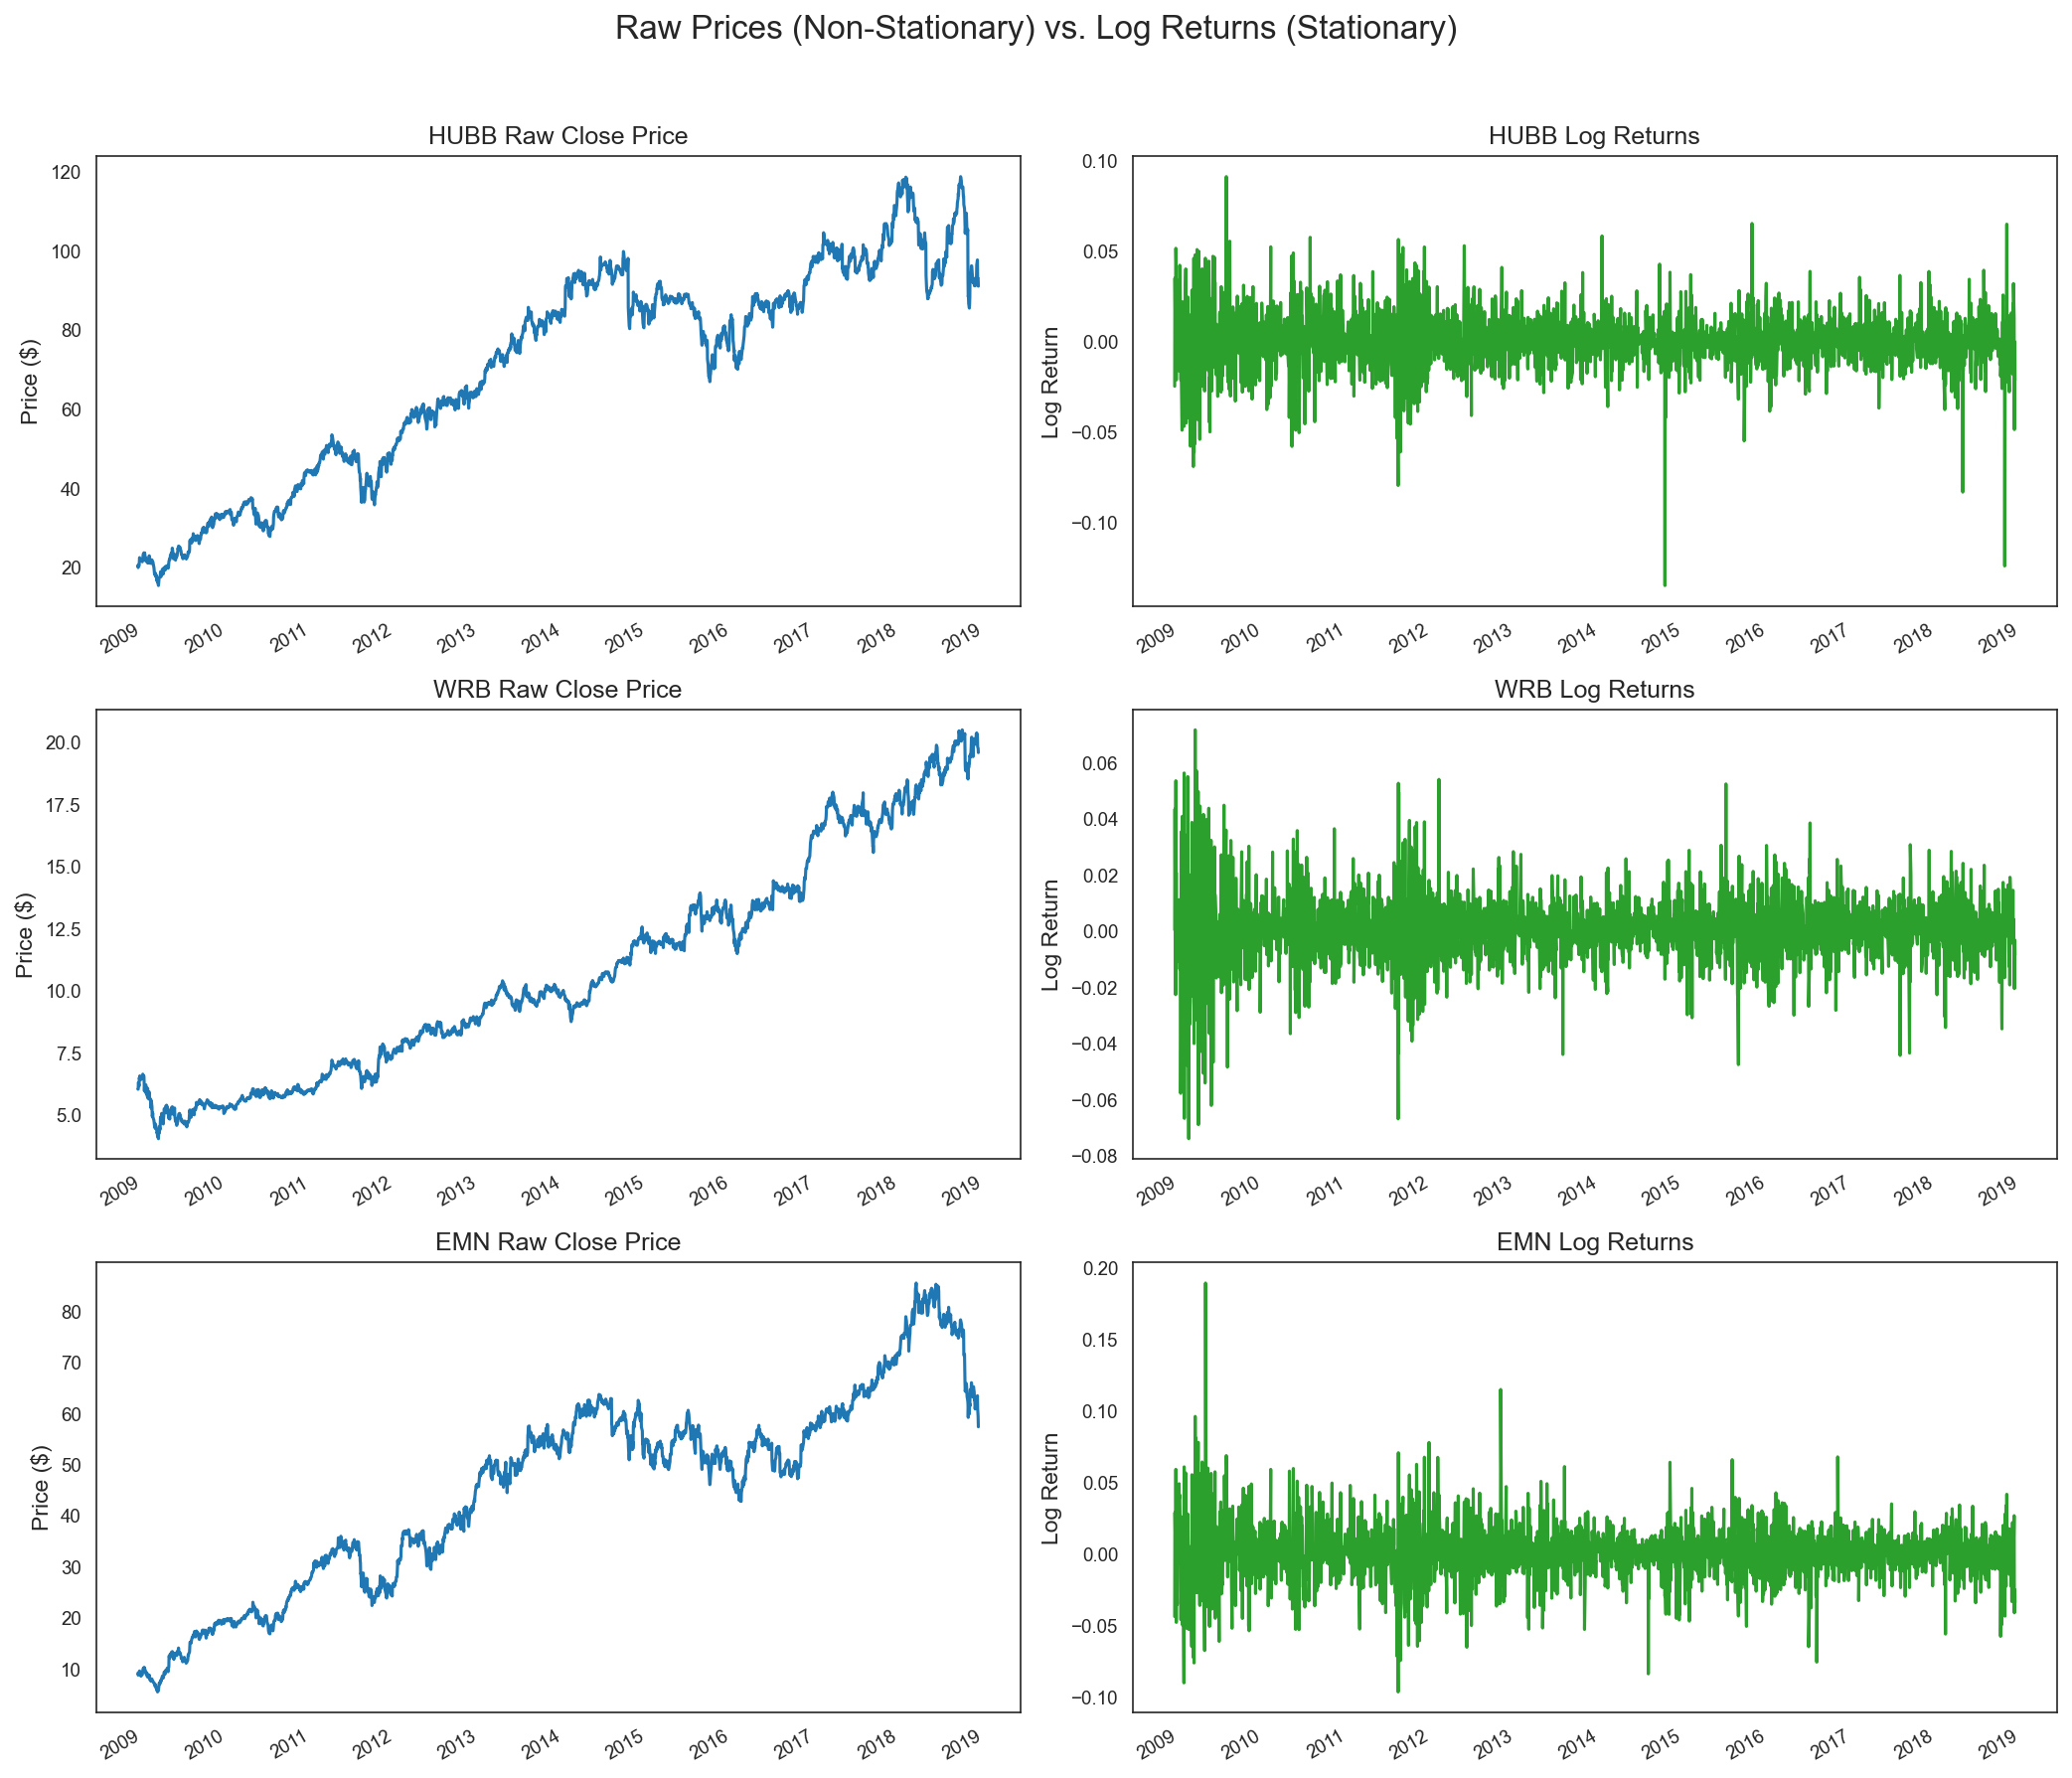

Step 5: Generating Plot (ACF/PACF)...


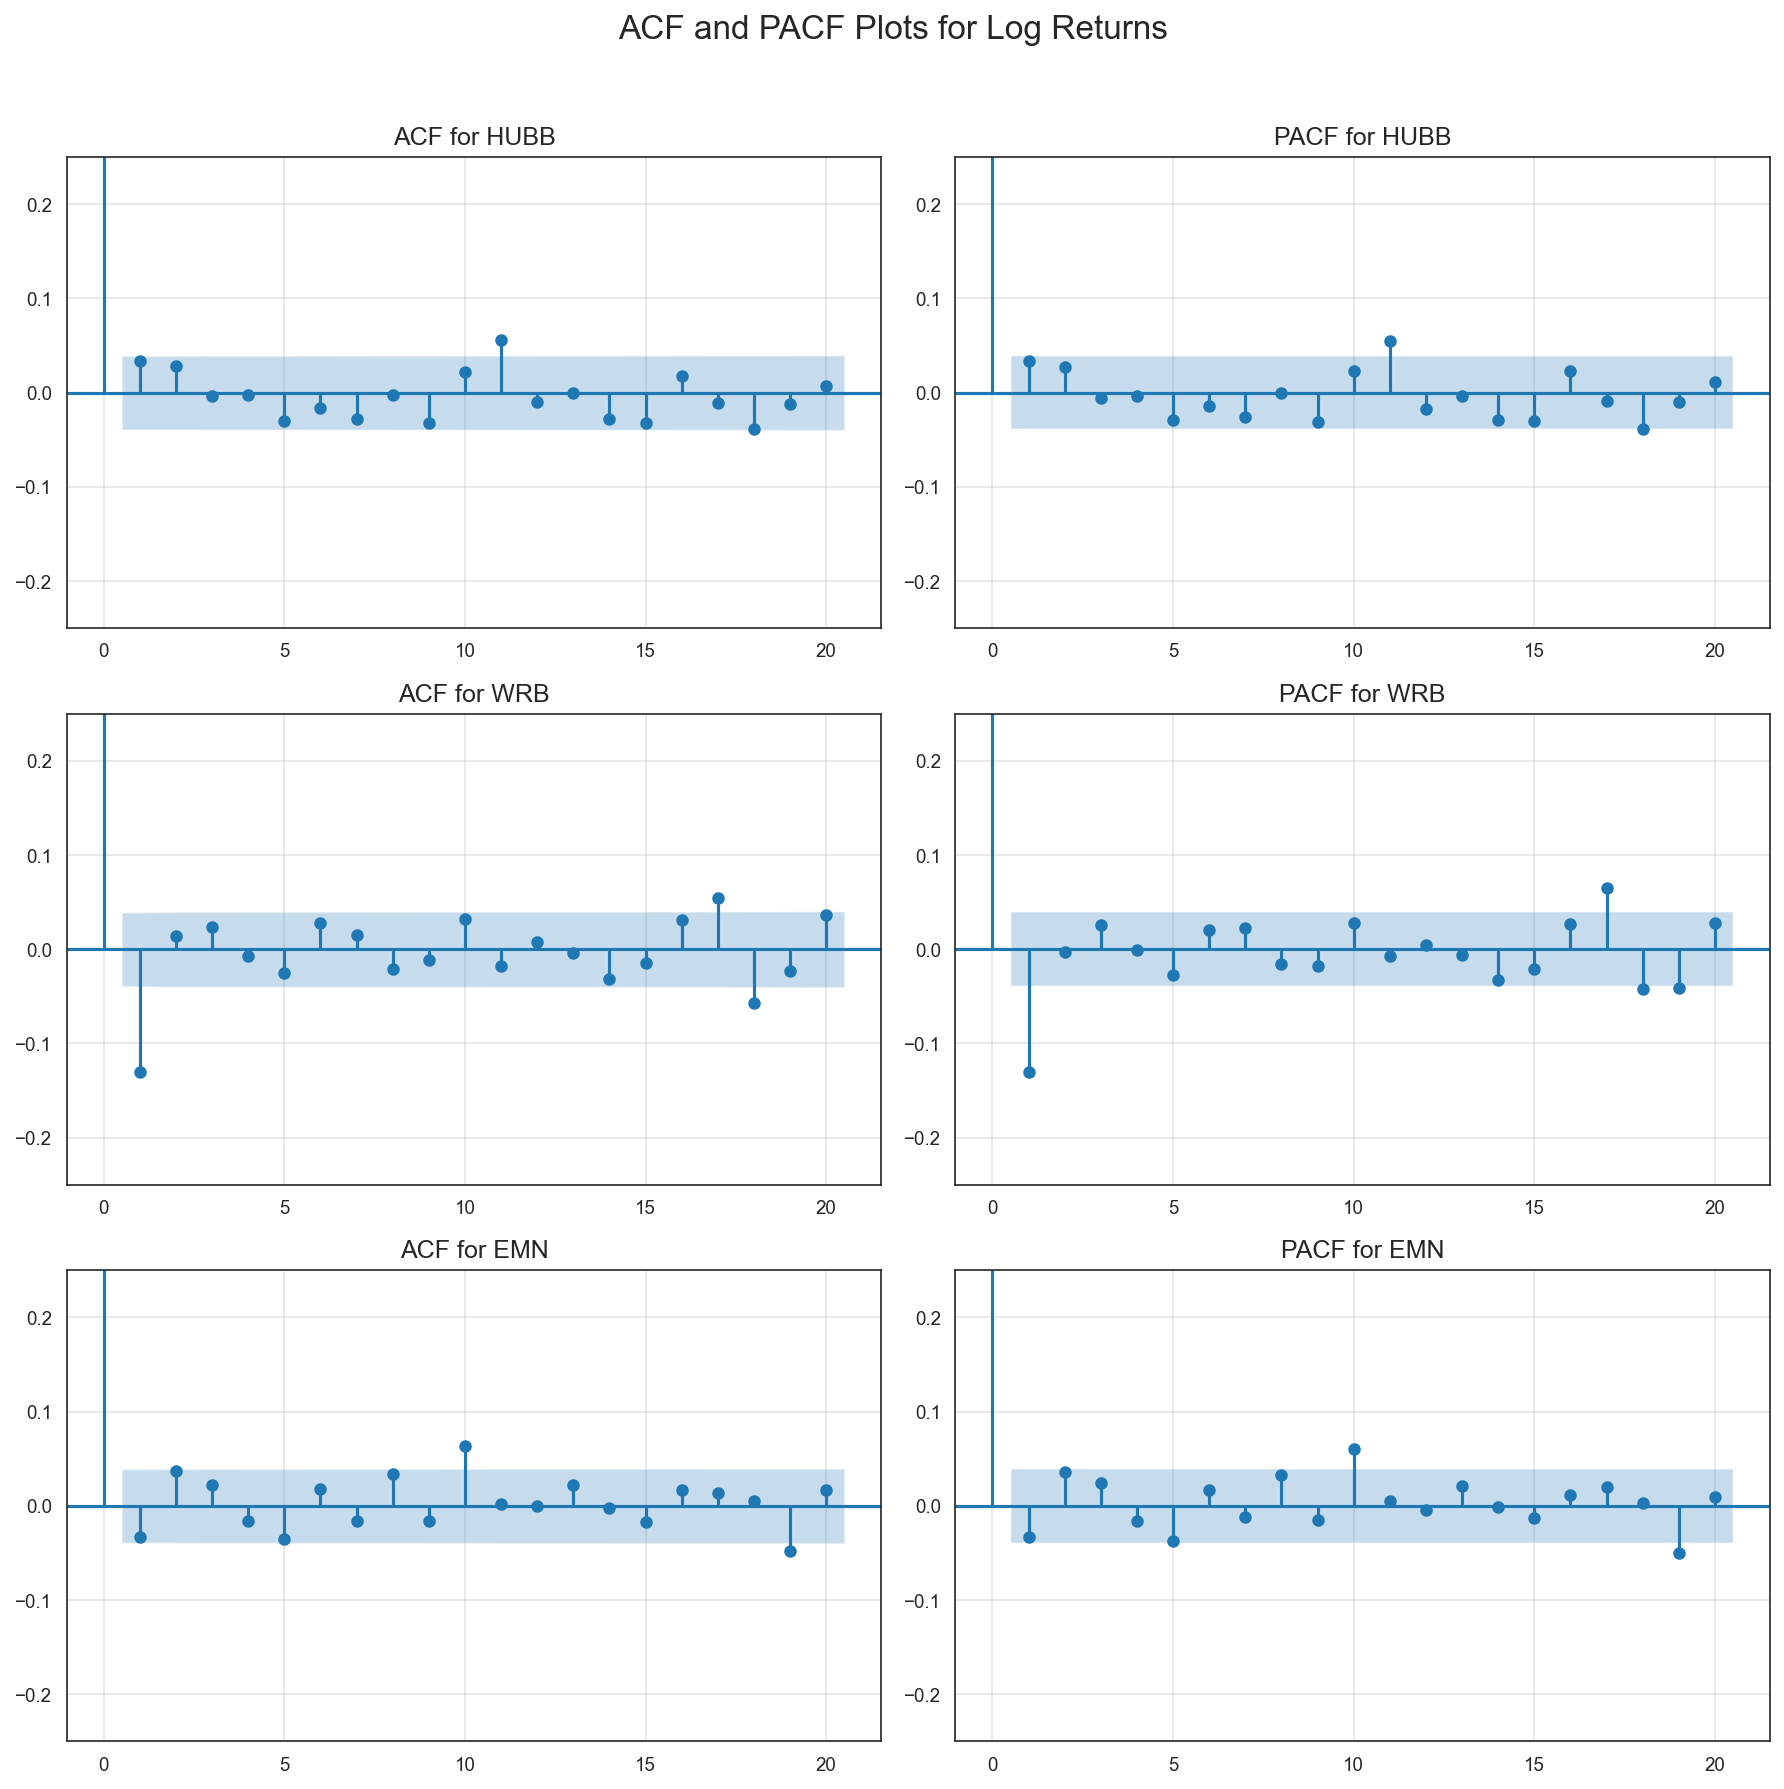

Step 6: Fitting Models (ARMA, ARCH, GARCH) & Forecasting Prices...
--- Processing HUBB ---
  Fitting ARMA...
  Fitting ARCH...
  Fitting GARCH...
--- Processing WRB ---
  Fitting ARMA...
  Fitting ARCH...
  Fitting GARCH...
--- Processing EMN ---
  Fitting ARMA...
  Fitting ARCH...
  Fitting GARCH...
Step 7: Generating Plot (Forecasts vs Actual Prices)...


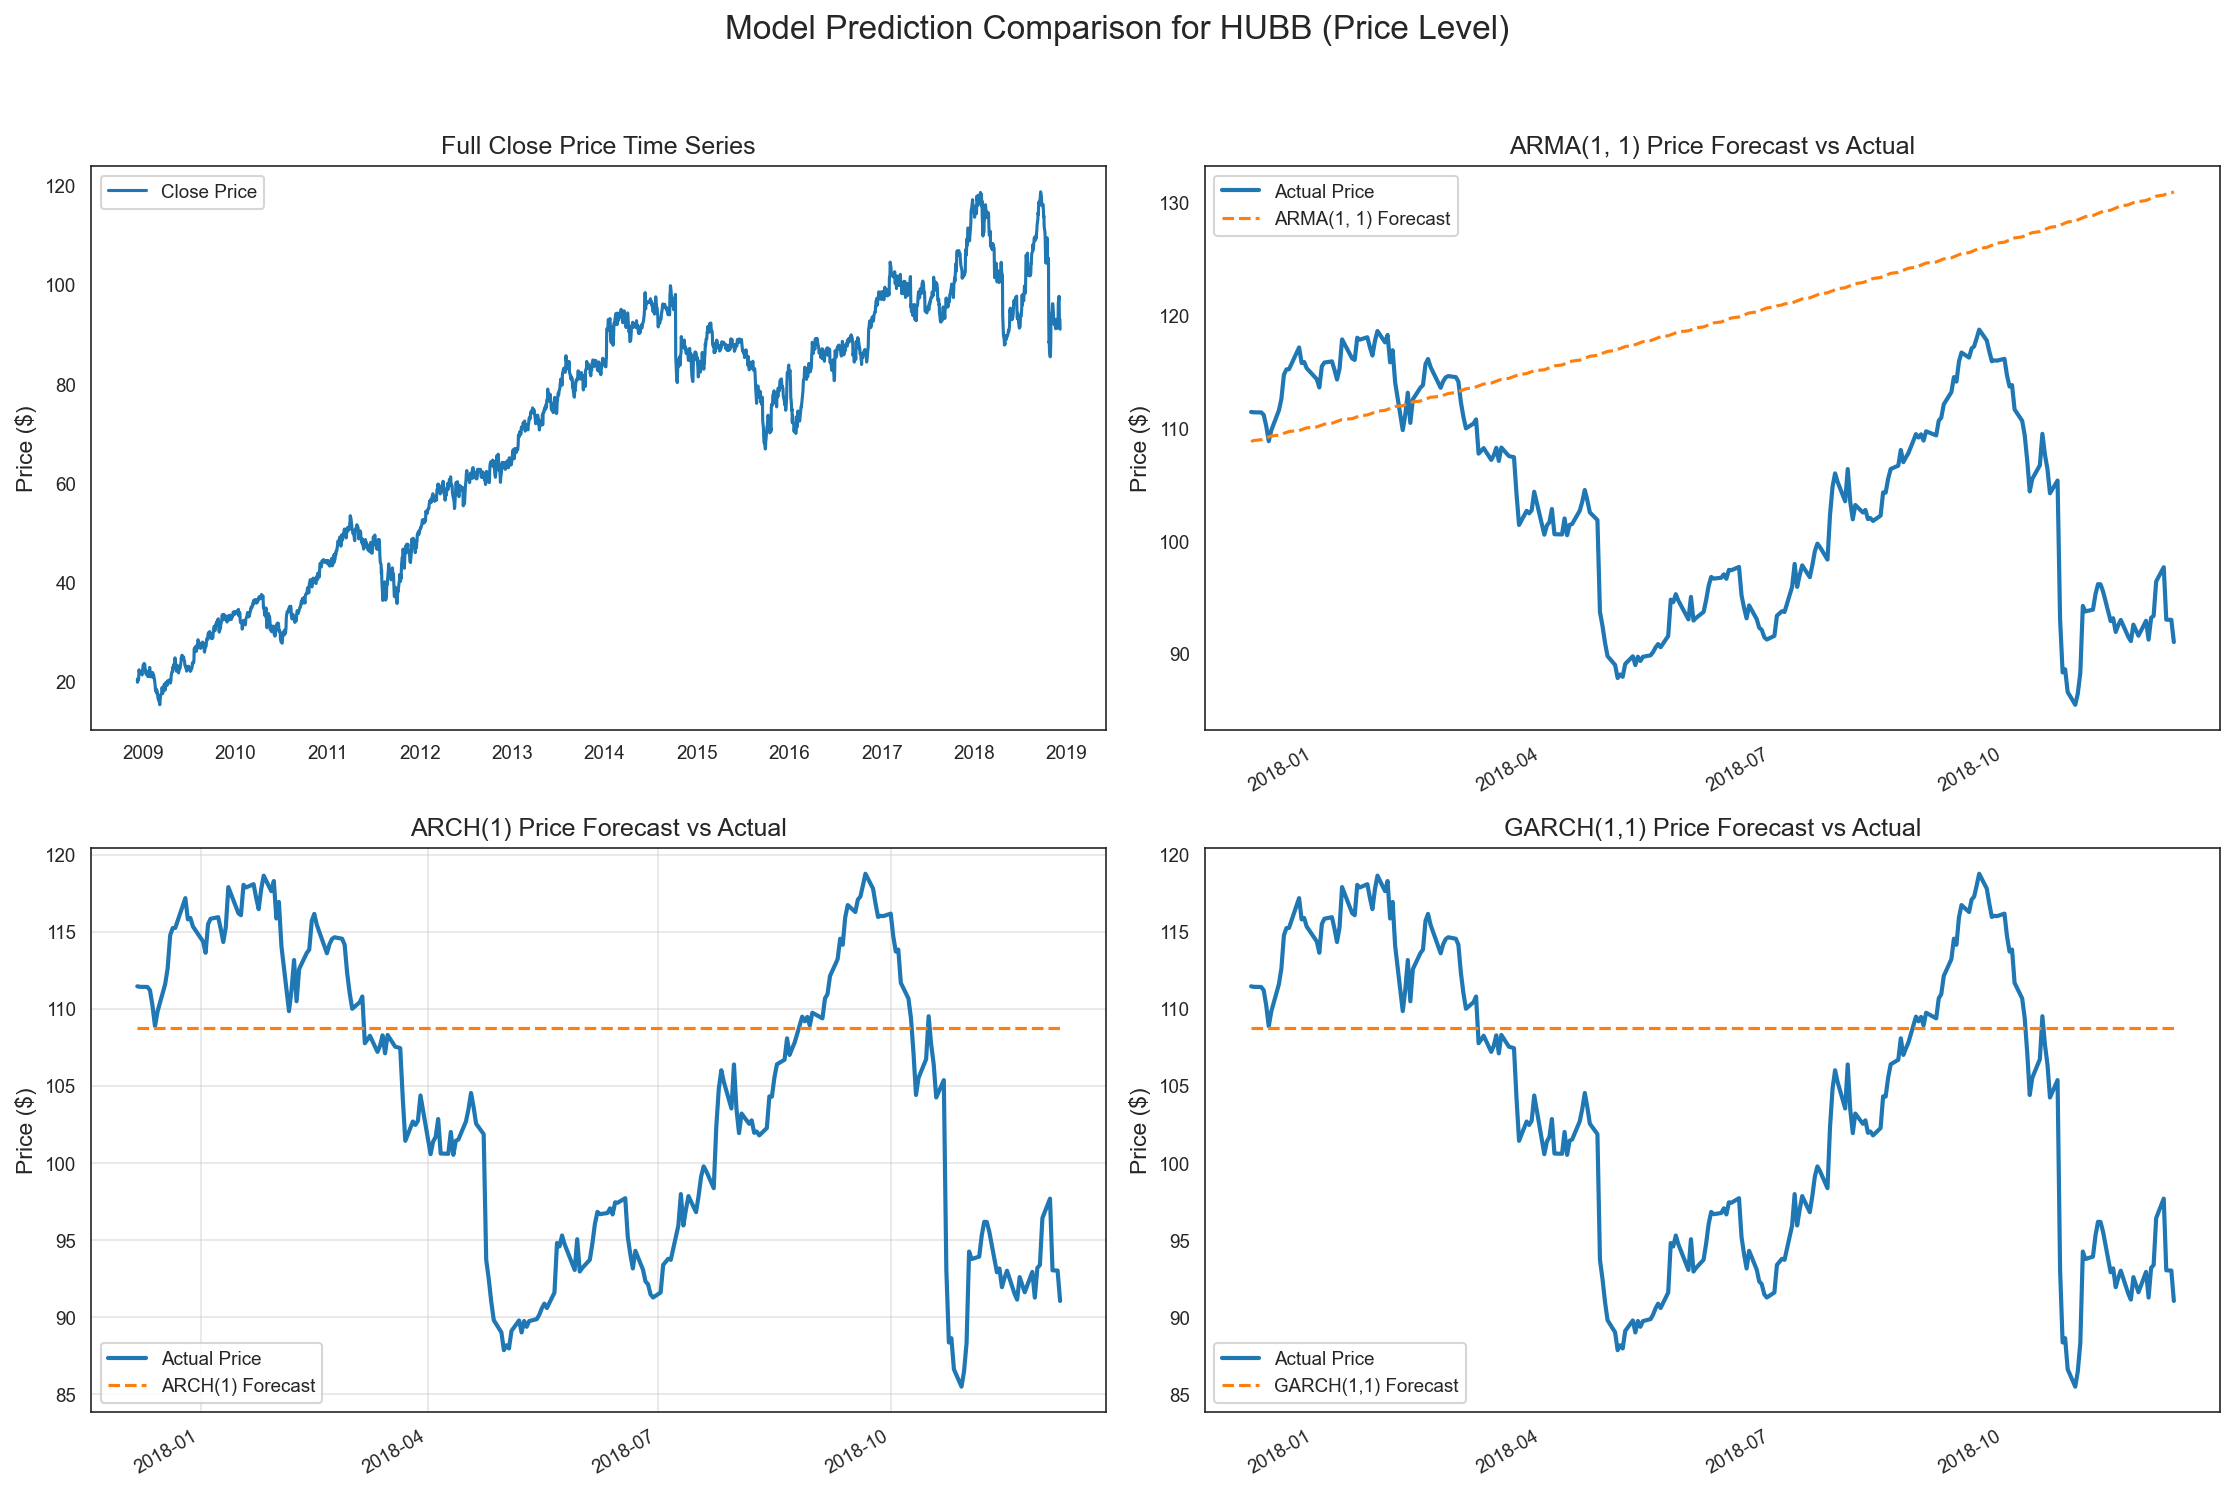

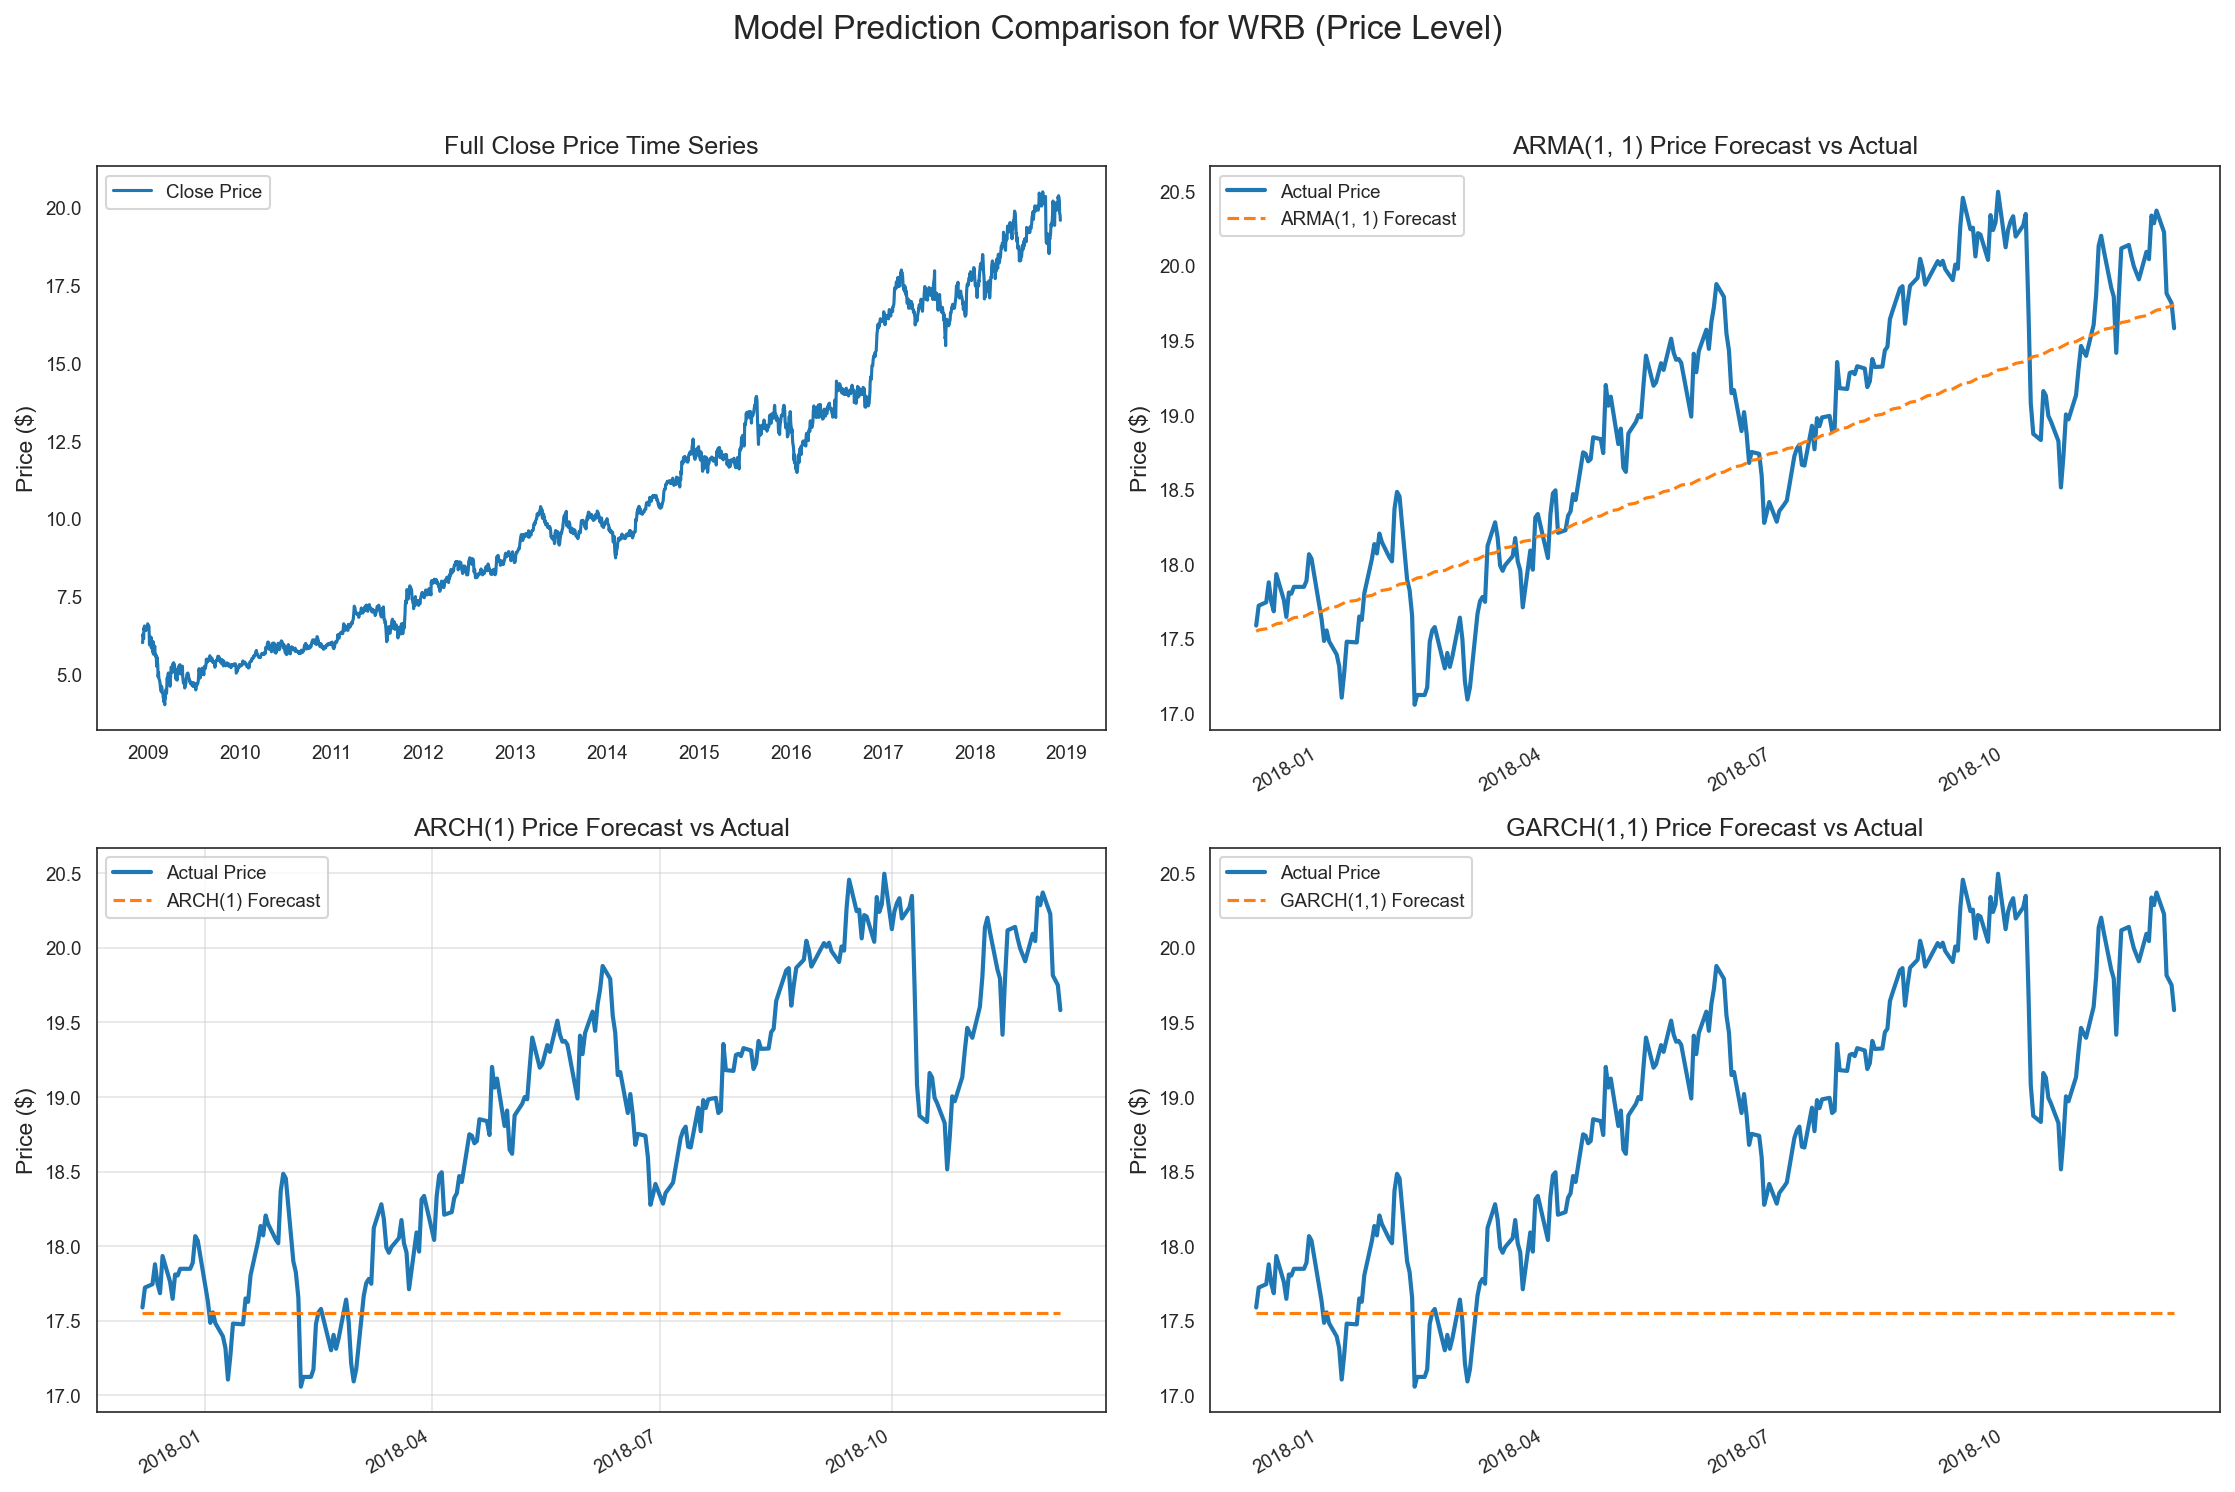

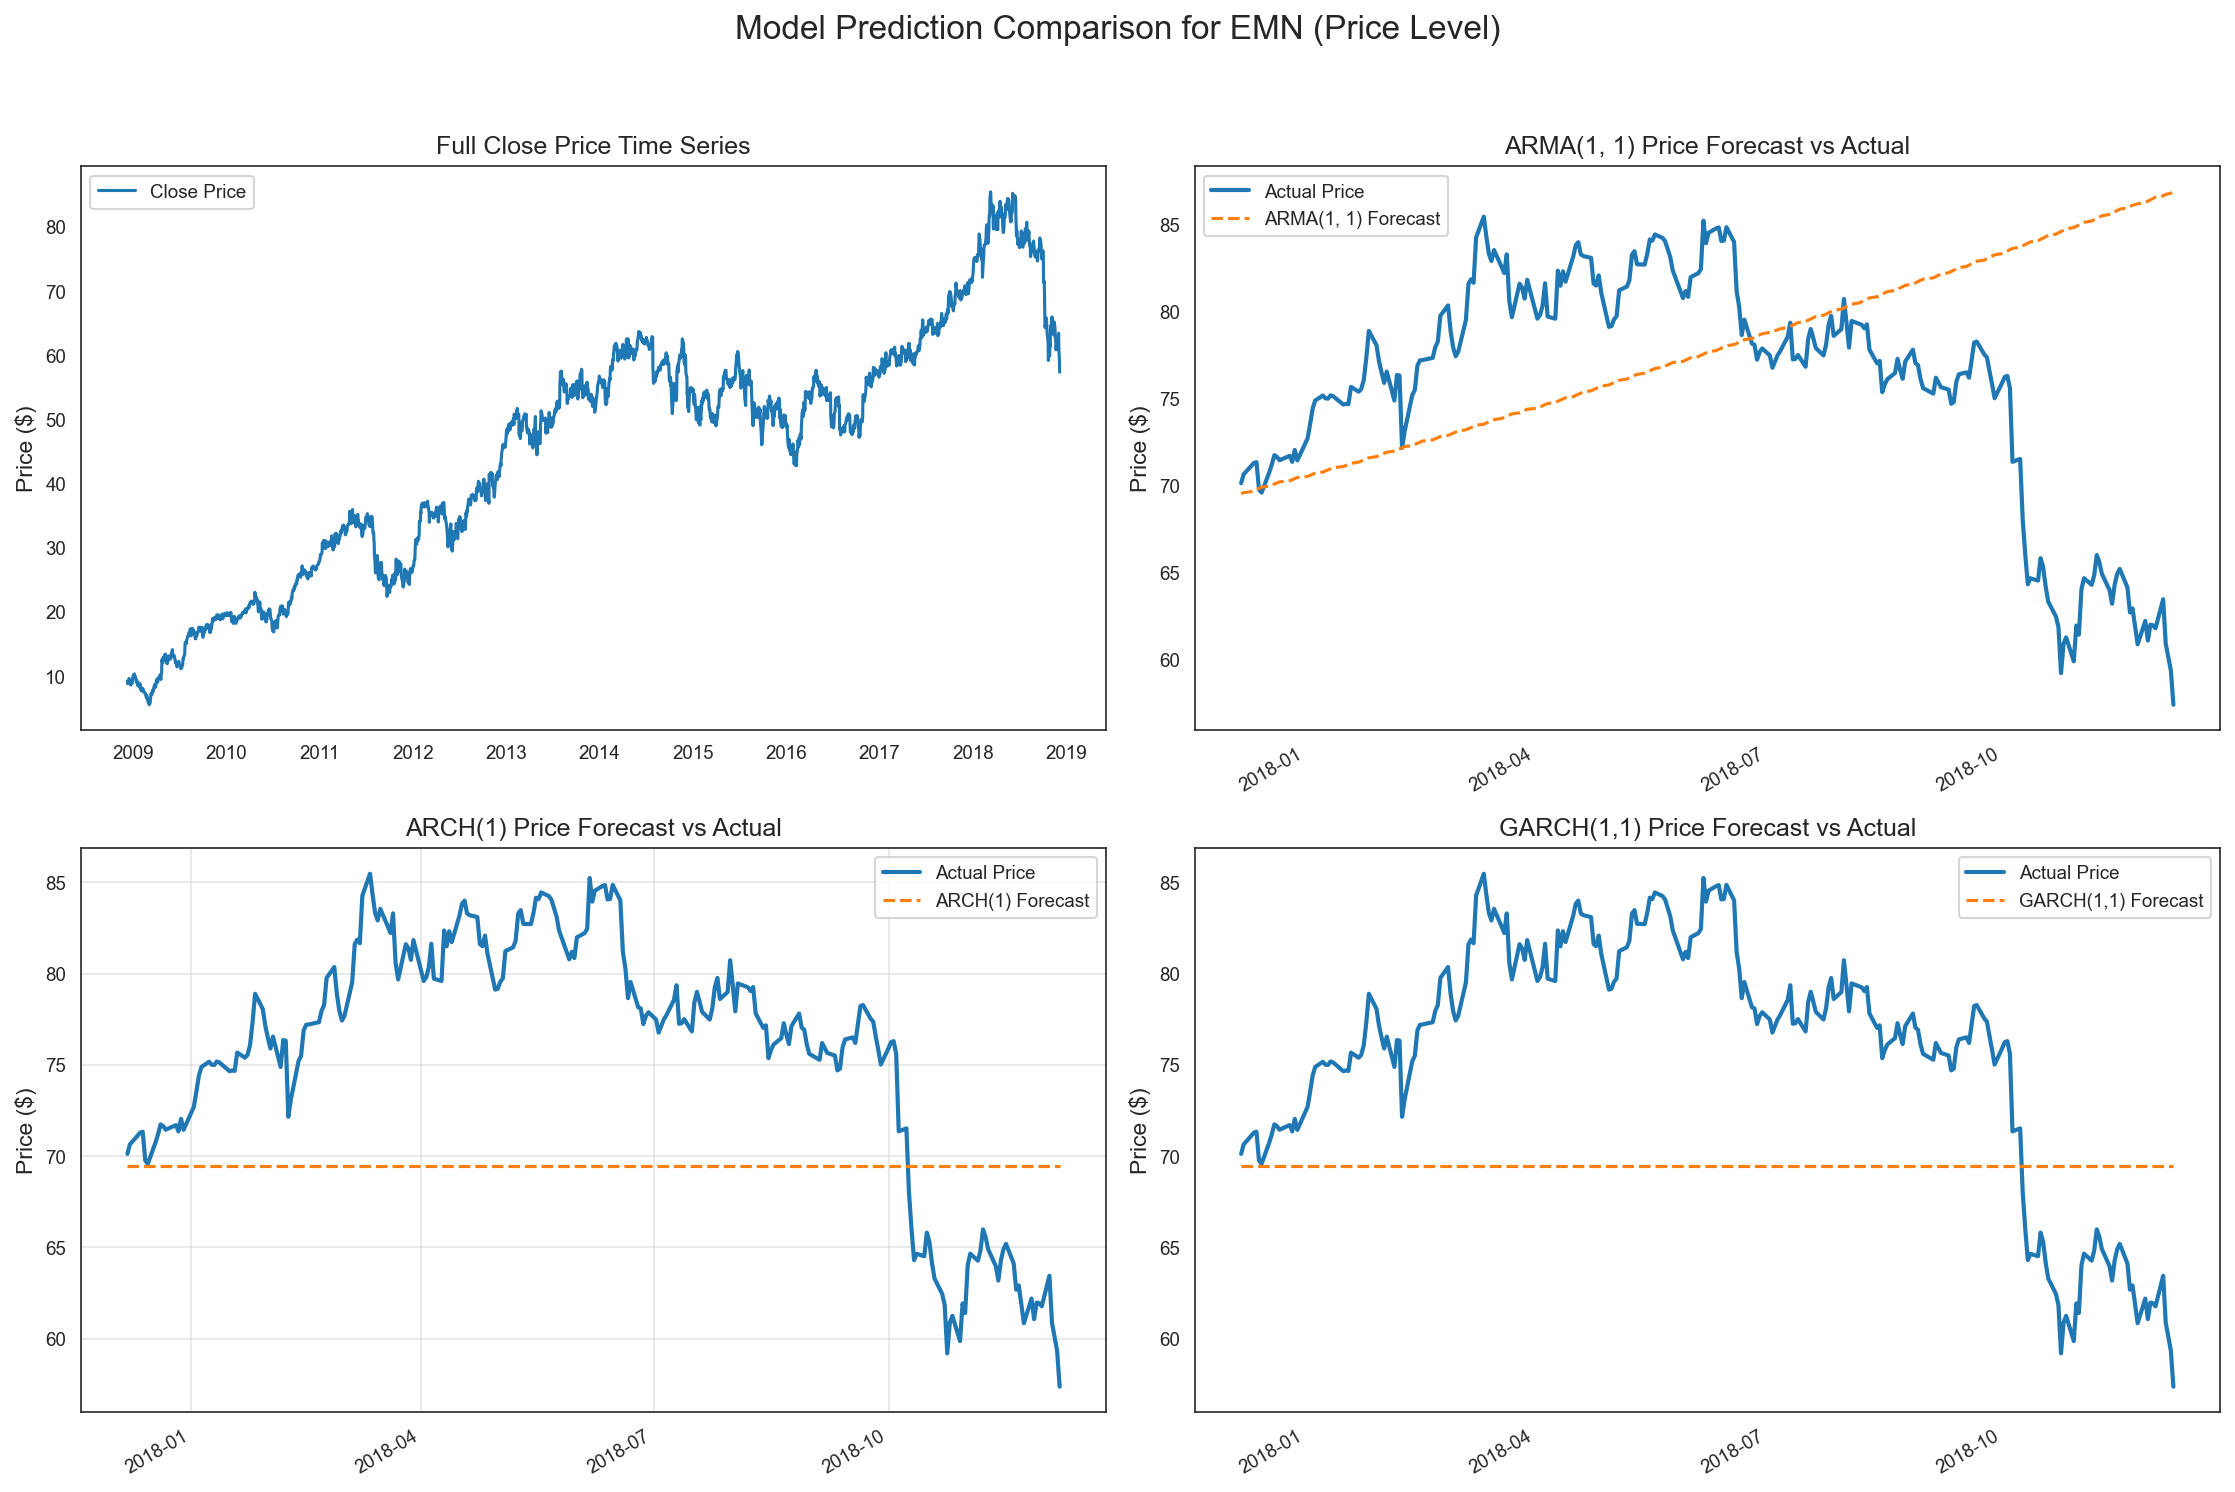

Step 8: Generating Plot (Volatility Clustering)...


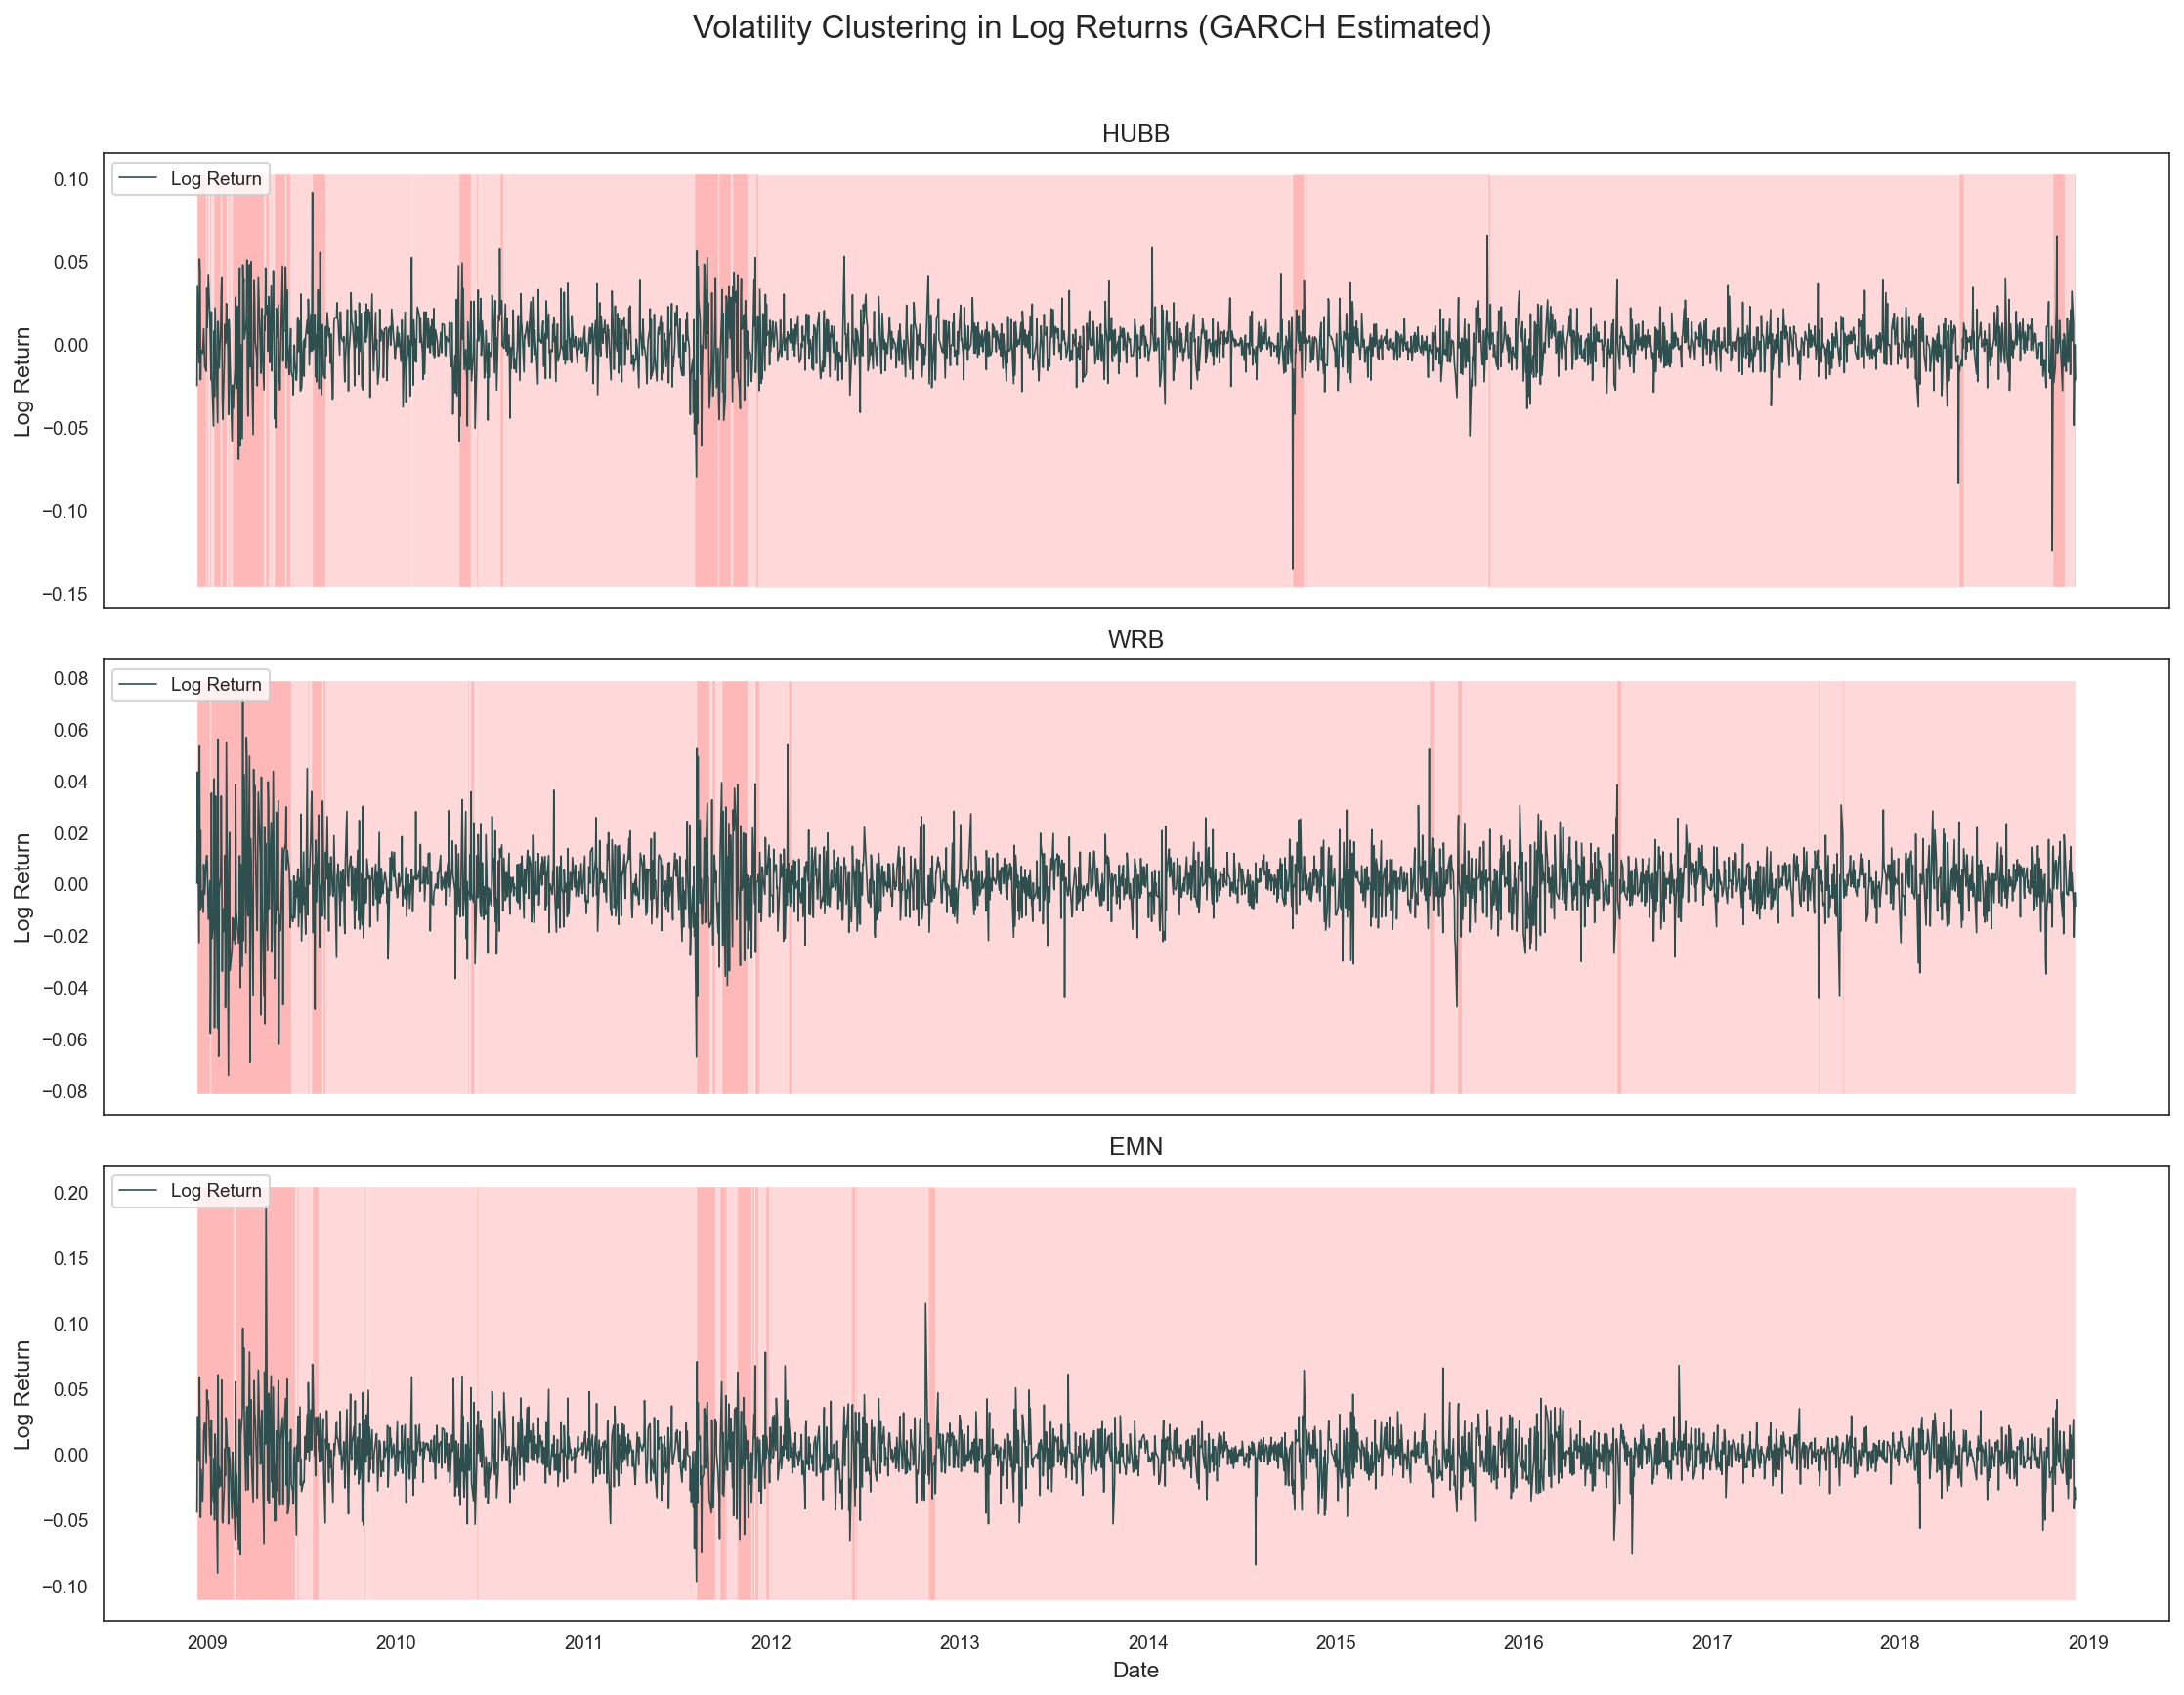

Analysis Complete.


In [ ]:
# =======================
# FTSE-250 Assignment (Question 1) - Modified Code
# Stocks: HUBB, WRB, EMN
# Period: 2008-12-10 to 2018-12-10
# Goal: Replicate PDF plot styles
# =======================

# ---------- Imports ----------
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.dates as mdates # For date formatting

# ---------- Step 1: Download Data ----------
tickers = ["HUBB", "WRB", "EMN"]
start, end = "2008-12-10", "2018-12-10"

data = yf.download(tickers, start=start, end=end)["Close"]
data.dropna(inplace=True) # Drop rows with NAs if any ticker missing data
print("="*40)
print("Step 1: Data Download Complete")
print("Downloaded data shape:", data.shape)
print(data.head()) 

# ---------- Step 2: Calculate Log Returns ----------
log_returns = np.log(data / data.shift(1)).dropna()
print("="*40)
print("Step 2: Log Returns Calculated")
print(log_returns.head()) 


# ---------- Step 3: ADF Tests (Verify Observations from PDF) ----------
print("="*40)
print("Step 3: Stationarity Tests (ADF)")
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"  ADF Test for {name}: p-value = {p_value:.4f} -> {'Stationary' if p_value < 0.05 else 'Non-Stationary'}")
    return p_value

print("--- Raw Prices ---")
for t in tickers:
    adf_test(data[t], f"{t} Raw Price")

print("\n--- Log Returns ---")
for t in tickers:
    adf_test(log_returns[t], f"{t} Log Return")

# ---------- Step 4: Plot Raw Prices vs. Log Returns (like PDF Page 1) ----------
print("="*40)
print("Step 4: Generating Plot (Raw Prices vs Log Returns)...")

fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)), sharex=False) # Changed sharex
fig.suptitle('Raw Prices (Non-Stationary) vs. Log Returns (Stationary)', fontsize=16, y=0.99) # Match title [cite: 13]

for i, ticker in enumerate(tickers):
    # Plot Raw Price
    ax_price = axes[i, 0]
    ax_price.plot(data.index, data[ticker], label=f'{ticker} Raw Price')
    ax_price.set_title(f'{ticker} Raw Close Price') # Match title 
    ax_price.set_ylabel('Price ($)') # Match label [cite: 1, 3, 7]
    

    # Plot Log Return
    ax_return = axes[i, 1]
    ax_return.plot(log_returns.index, log_returns[ticker], label=f'{ticker} Log Return', color='tab:green')
    ax_return.set_title(f'{ticker} Log Returns') # Match title [cite: 20, 40, 43, 51]
    ax_return.set_ylabel('Log Return') # Match label [cite: 35, 46]


    # Set common x-axis formatting for date visibility
    for ax in [ax_price, ax_return]:
         ax.xaxis.set_major_locator(mdates.YearLocator(1)) # Tick every1 1years
         ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Show only year
         plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Adjust layout slightly
plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust rect based on title presence [cite: 21]
plt.show()

# ---------- Step 5: Plot ACF and PACF (like PDF Page 3) ----------
print("="*40)
print("Step 5: Generating Plot (ACF/PACF)...")

fig_acf, axes_acf = plt.subplots(len(tickers), 2, figsize=(12, 4 * len(tickers)))
fig_acf.suptitle('ACF and PACF Plots for Log Returns', fontsize=16, y=0.99) # Match title [cite: 111, 137]

for i, ticker in enumerate(tickers):
    # ACF Plot
    plot_acf(log_returns[ticker], lags=20, ax=axes_acf[i, 0], title=f'ACF for {ticker}') # Match lags=20, title [cite: 113, 134, 136, 150]
    axes_acf[i, 0].set_ylim(-0.25, 0.25) # Match ylim [cite: 113]

    # PACF Plot
    plot_pacf(log_returns[ticker], lags=20, ax=axes_acf[i, 1], title=f'PACF for {ticker}', method='ywm') # Match lags=20, title [cite: 115, 165, 167, 175]
    axes_acf[i, 1].set_ylim(-0.25, 0.25) # Match ylim [cite: 116]

    # Add grid
    axes_acf[i, 0].grid(True, alpha=0.5)
    axes_acf[i, 1].grid(True, alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust rect [cite: 117]
plt.show()

# ---------- Step 6: Fit Models & Prepare Forecasts for Plotting (like PDF Page 4) ----------
print("="*40)
print("Step 6: Fitting Models (ARMA, ARCH, GARCH) & Forecasting Prices...")

# Use a longer forecast horizon, e.g., 1 year (approx 252 days) for visual comparison
forecast_horizon = 252
model_forecasts = {}

# Suggest ARMA order based on ACF/PACF (or use fixed as per original code/PDF examples)
# For simplicity and consistency with original code/PDF visuals, let's use ARMA(1,1)
# Note: PDF examples show ARMA(0,0) for TSCO and ARMA(1,1) for EBAY. We'll use (1,1) for all here.
arma_order = (1, 0, 1) # (p,d,q) - d=0 because log returns are stationary

for t in tickers:
    print(f"--- Processing {t} ---")
    # Prepare data
    price_series = data[t]
    return_series = log_returns[t] * 100 # Scale for GARCH

    # Split data: Keep last `forecast_horizon` points for testing
    train_returns = return_series[:-forecast_horizon]
    test_returns = return_series[-forecast_horizon:]
    train_prices = price_series[:-forecast_horizon]
    test_prices = price_series[-forecast_horizon:]
    last_train_price = train_prices.iloc[-1]
    test_dates = test_prices.index

    forecast_results = {}

    # --- ARMA Model ---
    try:
        print("  Fitting ARMA...")
        model_arma = ARIMA(train_returns / 100, order=arma_order).fit() # Fit on original scale returns
        # Forecast log returns
        log_ret_forecast_arma = model_arma.forecast(steps=forecast_horizon)
        # Convert log return forecast to price forecast
        cumulative_log_ret_arma = log_ret_forecast_arma.cumsum()
        price_forecast_arma = last_train_price * np.exp(cumulative_log_ret_arma)
        forecast_results['ARMA'] = price_forecast_arma
    except Exception as e:
        print(f"  ARMA fitting failed for {t}: {e}")
        forecast_results['ARMA'] = pd.Series(np.nan, index=test_dates) # Placeholder


    # --- ARCH Model ---
    try:
        print("  Fitting ARCH...")
        # Fit ARCH(1) assuming zero mean for returns (common for ARCH/GARCH)
        model_arch = arch_model(train_returns, mean='Zero', vol='ARCH', p=1 , q = 1 ).fit(disp='off')
        # Forecast mean (which is zero) and variance
        arch_forecast = model_arch.forecast(horizon=forecast_horizon, reindex=False)
        log_ret_forecast_arch = arch_forecast.mean.iloc[0] / 100 # Mean forecast (zero), scale back
        # Convert to price forecast (will be flat line based on last price due to zero mean forecast)
        cumulative_log_ret_arch = log_ret_forecast_arch.cumsum()
        price_forecast_arch = last_train_price * np.exp(cumulative_log_ret_arch)
        forecast_results['ARCH'] = price_forecast_arch
    except Exception as e:
        print(f"  ARCH fitting failed for {t}: {e}")
        forecast_results['ARCH'] = pd.Series(np.nan, index=test_dates) # Placeholder


    # --- GARCH Model ---
    try:
        print("  Fitting GARCH...")
        # Fit GARCH(1,1) assuming zero mean
        model_garch = arch_model(train_returns, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
        # Forecast mean (zero) and variance
        garch_forecast = model_garch.forecast(horizon=forecast_horizon, reindex=False)
        log_ret_forecast_garch = garch_forecast.mean.iloc[0] / 100 # Mean forecast (zero), scale back
        # Convert to price forecast (also flat line)
        cumulative_log_ret_garch = log_ret_forecast_garch.cumsum()
        price_forecast_garch = last_train_price * np.exp(cumulative_log_ret_garch)
        forecast_results['GARCH'] = price_forecast_garch
    except Exception as e:
        print(f"  GARCH fitting failed for {t}: {e}")
        forecast_results['GARCH'] = pd.Series(np.nan, index=test_dates) # Placeholder

    model_forecasts[t] = {
        'full_prices': price_series,
        'test_prices': test_prices,
        'forecasts': forecast_results
    }

# ---------- Step 7: Plot Forecasts vs Actual Prices (like PDF Page 4) ----------
print("="*40)
print("Step 7: Generating Plot (Forecasts vs Actual Prices)...")

for t in tickers:
    if t not in model_forecasts: continue # Skip if processing failed

    results = model_forecasts[t]
    full_prices = results['full_prices']
    test_prices = results['test_prices']
    forecasts = results['forecasts']
    test_dates = test_prices.index

    fig_fc, axes_fc = plt.subplots(2, 2, figsize=(15, 10))
    fig_fc.suptitle(f'Model Prediction Comparison for {t} (Price Level)', fontsize=16, y=0.99) # Match title 

    # 1. Full Close Price Time Series
    axes_fc[0, 0].plot(full_prices.index, full_prices, label='Close Price')
    axes_fc[0, 0].set_title('Full Close Price Time Series') # Match title 
    axes_fc[0, 0].set_ylabel('Price ($)')
    axes_fc[0, 0].legend()


    # 2. ARMA Forecast vs Actual
    axes_fc[0, 1].plot(test_dates, test_prices, label='Actual Price', linewidth=2)
    if 'ARMA' in forecasts:
        axes_fc[0, 1].plot(test_dates, forecasts['ARMA'], label=f'ARMA{arma_order[0], arma_order[2]} Forecast', linestyle='--')
    axes_fc[0, 1].set_title(f'ARMA{arma_order[0], arma_order[2]} Price Forecast vs Actual') # Match title 
    axes_fc[0, 1].set_ylabel('Price ($)')
    axes_fc[0, 1].legend()
   

    # 3. ARCH Forecast vs Actual
    axes_fc[1, 0].plot(test_dates, test_prices, label='Actual Price', linewidth=2)
    if 'ARCH' in forecasts:
        axes_fc[1, 0].plot(test_dates, forecasts['ARCH'], label='ARCH(1) Forecast', linestyle='--')
    axes_fc[1, 0].set_title('ARCH(1) Price Forecast vs Actual') # Match title 
    axes_fc[1, 0].set_ylabel('Price ($)')
    axes_fc[1, 0].legend()
    axes_fc[1, 0].grid(True, alpha=0.5)

    # 4. GARCH Forecast vs Actual
    axes_fc[1, 1].plot(test_dates, test_prices, label='Actual Price', linewidth=2)
    if 'GARCH' in forecasts:
        axes_fc[1, 1].plot(test_dates, forecasts['GARCH'], label='GARCH(1,1) Forecast', linestyle='--')
    axes_fc[1, 1].set_title('GARCH(1,1) Price Forecast vs Actual') # Match title 
    axes_fc[1, 1].set_ylabel('Price ($)')
    axes_fc[1, 1].legend()
   

    # Apply date formatting to forecast plots
    for ax in [axes_fc[0, 1], axes_fc[1, 0], axes_fc[1, 1]]:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # Tick every 3 months
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format as YYYY-MM
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ---------- Step 8: Plot Volatility Clustering (like PDF Page 5) ----------
print("="*40)
print("Step 8: Generating Plot (Volatility Clustering)...")

fig_vol, axes_vol = plt.subplots(len(tickers), 1, figsize=(15, 4 * len(tickers)), sharex=True)
if len(tickers) == 1: axes_vol = [axes_vol] # Make it iterable if only one ticker
fig_vol.suptitle('Volatility Clustering in Log Returns (GARCH Estimated)', fontsize=16, y=0.99) # Match title [cite: 325]

for i, ticker in enumerate(tickers):
    ax = axes_vol[i]
    returns_scaled = log_returns[ticker] * 100 # Scale for fitting

    try:
        # Fit GARCH(1,1) to the *full* series to estimate historical volatility
        garch_full = arch_model(returns_scaled, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
        conditional_volatility = garch_full.conditional_volatility

        # Plot log returns (original scale)
        ax.plot(log_returns.index, log_returns[ticker], label='Log Return', color='darkslategray', linewidth=0.8)

        # Identify high volatility periods (e.g., > 1.5 * mean volatility)
        vol_threshold = 1.5 * conditional_volatility.mean()
        high_vol_periods = log_returns.index[conditional_volatility > vol_threshold]

        # Shade high volatility regions using fill_between
        # We need to find contiguous blocks for shading
        if not high_vol_periods.empty:
             is_high = conditional_volatility > vol_threshold
             start_indices = np.where(is_high & ~is_high.shift(fill_value=False))[0]
             end_indices = np.where(~is_high & is_high.shift(fill_value=False))[0]

             # Handle edge cases where series starts or ends in high vol
             if is_high.iloc[0]:
                 start_indices = np.insert(start_indices, 0, 0)
             if is_high.iloc[-1]:
                 end_indices = np.append(end_indices, len(log_returns) - 1)

             # Ensure start and end indices match up
             if len(start_indices) > len(end_indices):
                 end_indices = np.append(end_indices, len(log_returns) - 1)
             elif len(end_indices) > len(start_indices):
                  start_indices = np.insert(start_indices, 0, 0)

             min_ret, max_ret = ax.get_ylim() # Get y-limits for shading
             for start, end in zip(start_indices, end_indices):
                  # Ensure indices are within bounds
                  start_idx = max(0, start)
                  end_idx = min(len(log_returns)-1, end)
                  if start_idx < end_idx: # Check if valid range
                       ax.fill_between(log_returns.index[start_idx:end_idx+1], min_ret, max_ret,
                                       color='red', alpha=0.15, edgecolor=None)


        ax.set_title(ticker) # Match title [cite: 344, 343, 342]
        ax.set_ylabel('Log Return') # Match label [cite: 306, 307, 308]
        ax.legend(loc='upper left')

    except Exception as e:
        print(f"  GARCH fitting/plotting failed for {ticker}: {e}")
        ax.set_title(f"{ticker} - GARCH Failed")

# Final date formatting for the last axis
axes_vol[-1].set_xlabel('Date') # Match label [cite: 346]
axes_vol[-1].xaxis.set_major_locator(mdates.YearLocator(1)) # Tick every year
axes_vol[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Show year
plt.setp(axes_vol[-1].get_xticklabels(), rotation=0, ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect
plt.show()

print("="*40)
print("Analysis Complete.")

# (Optional: Keep RMSE calculation if needed, but it wasn't plotted in PDF page 4)
# print("\nRecalculating RMSE for Log Return Forecasts (where applicable):")
# results_rmse = {}
# for t in tickers:
#     try:
#         r = log_returns[t]
#         train, test = r[:-forecast_horizon], r[-forecast_horizon:]
#         arma_fit = ARIMA(train, order=arma_order).fit()
#         pred_arma_ret = arma_fit.forecast(len(test))
#         rmse_arma_ret = sqrt(mean_squared_error(test, pred_arma_ret))
#         results_rmse[t] = [rmse_arma_ret] # Add more models if needed
#     except:
#         results_rmse[t] = [np.nan]
# rmse_ret_df = pd.DataFrame(results_rmse, index=["ARMA(1,1)_LogRet"])
# print(rmse_ret_df)